In [1]:
# step1. load data and NMF

/var/folders/9v/25ky5ynx3fv57ncrm5lt41980000gn/T/ipykernel_8354/1040791103.py:171: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(measure_cols, rotation=30, ha="right")


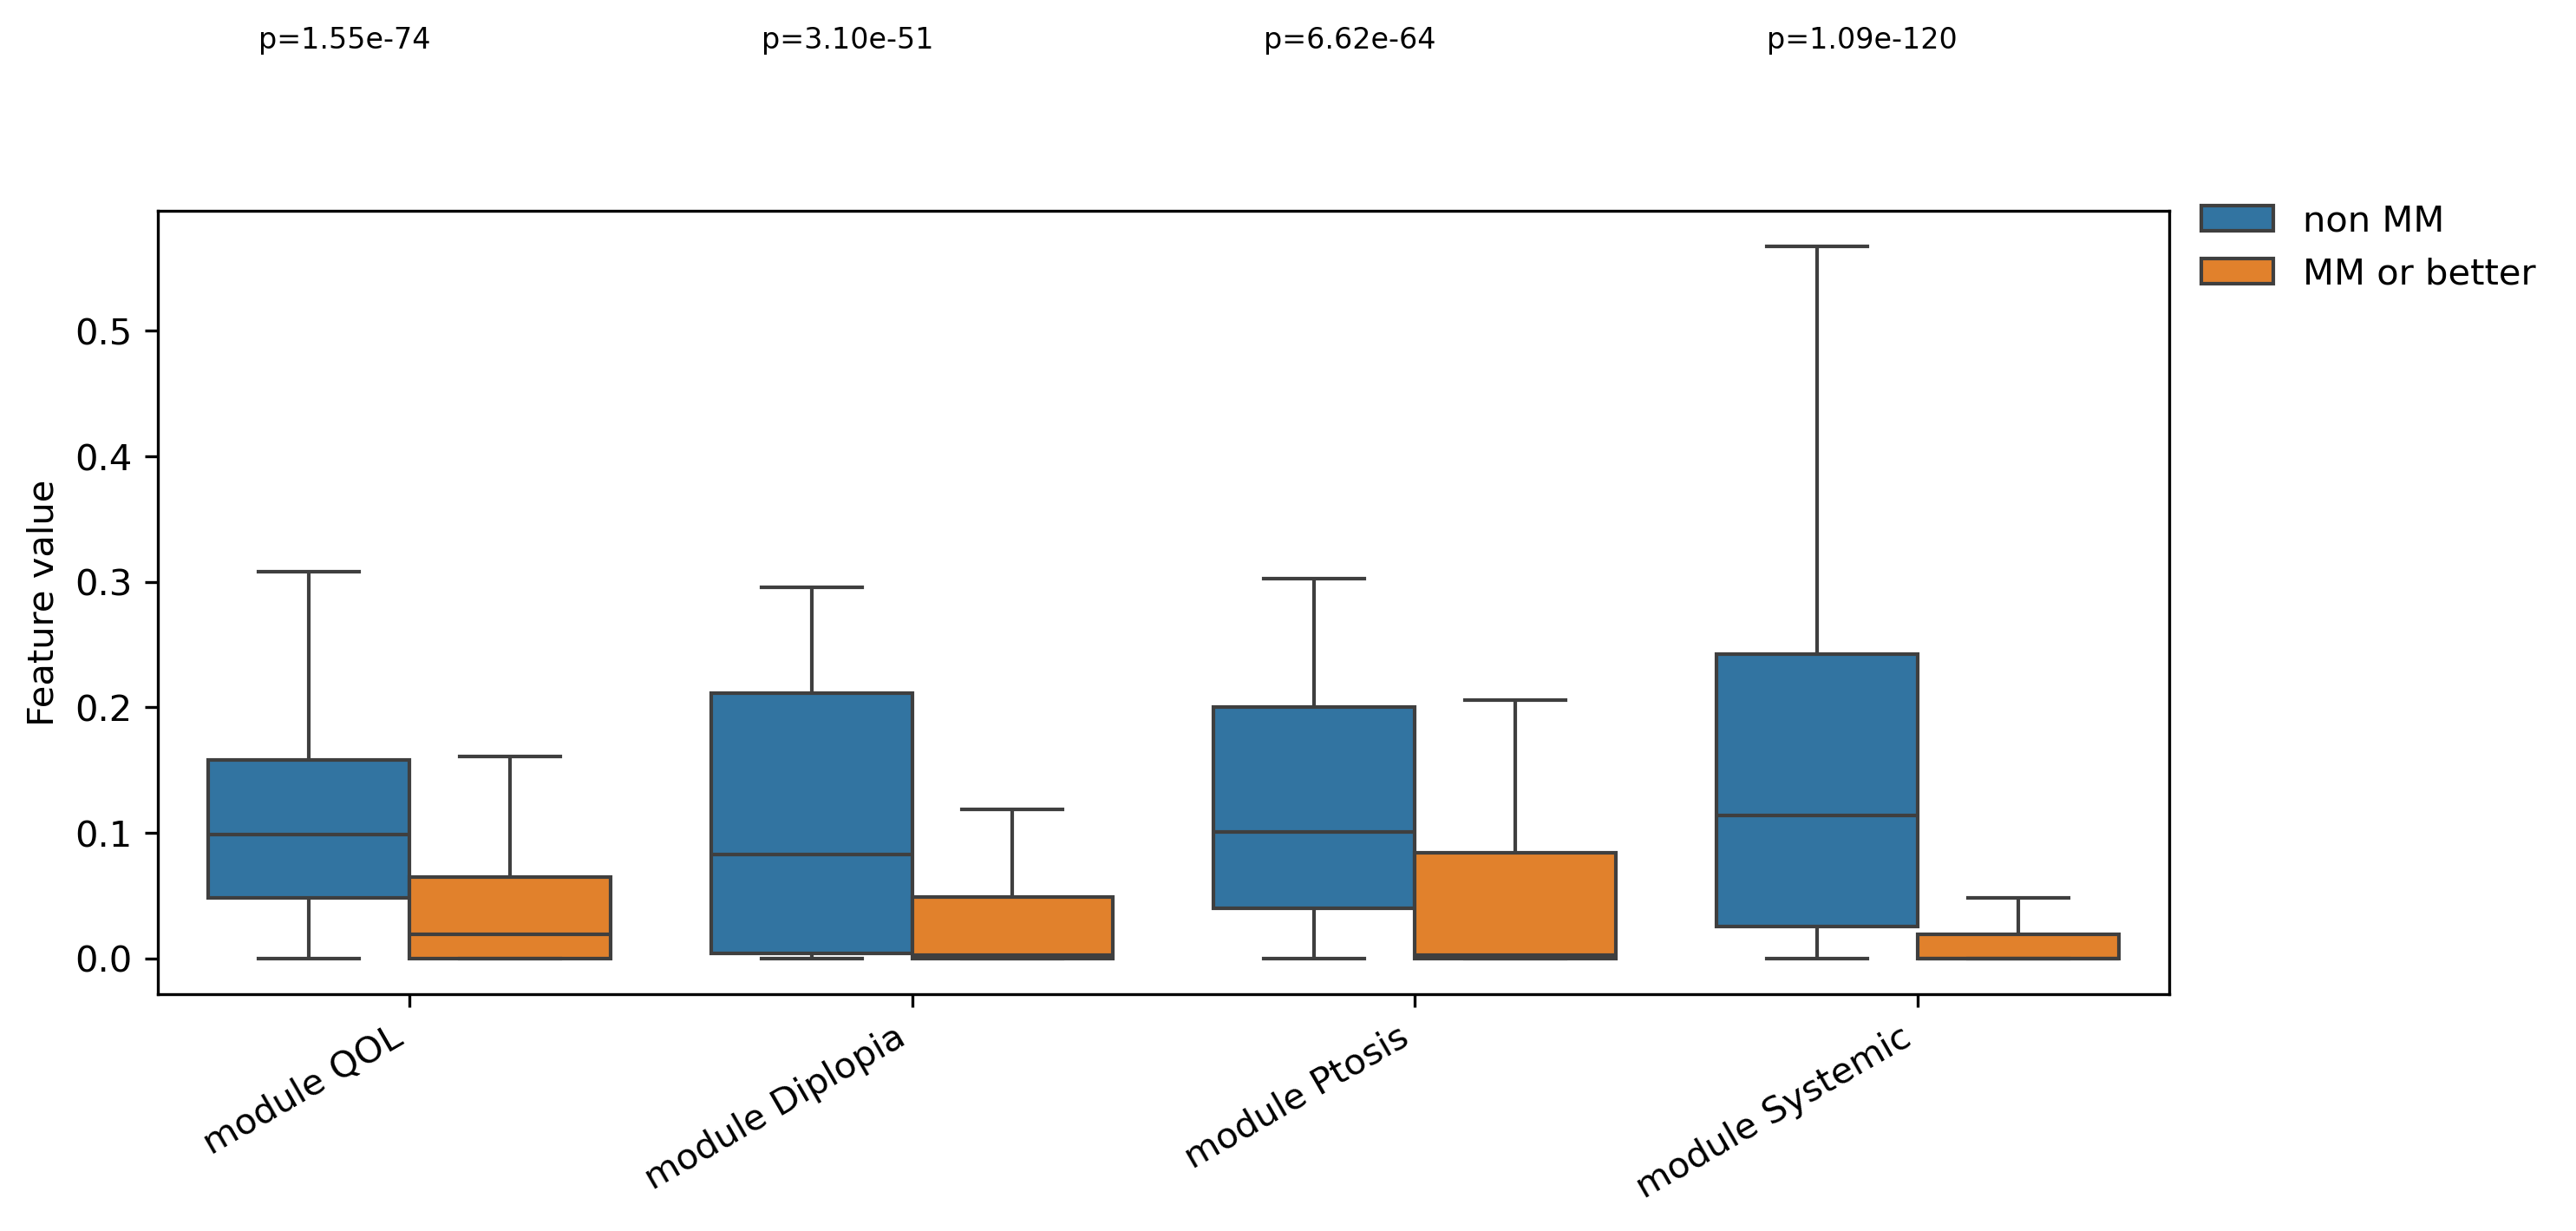

In [2]:
import os
import pickle
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import NMF
from scipy.cluster.hierarchy import linkage, leaves_list

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# --------------------
# 1) 入力設定・列名
# --------------------
config = {"filepath": "./data/df_4th.csv"}

df_names = [
    "MGC_ptosis", "MGC_diplopia", "MGC_eyelid_closure", "MGC_speech", "MGC_chewing", 
    "MGC_swallowing", "MGC_respiration", "MGC_neck", "MGC_upper_limb", "MGC_lower_limb",
    "MGADL_speech", "MGADL_chewing", "MGADL_swallowing", "MGADL_respiration", 
    "MGADL_toothbrushing", "MGADL_getting_up", "MGADL_diplopia", "MGADL_ptosis",
    "MGQOL1_dissatisfaction", "MGQOL2_seeing", "MGQOL3_eating", 
    "MGQOL4_social_activity_restriction", "MGQOL5_hobby_entertainment", "MGQOL6_family_role", 
    "MGQOL7_behavior_modification", "MGQOL8_work_impact", "MGQOL9_speaking", 
    "MGQOL10_driving", "MGQOL11_feeling_down", "MGQOL12_walking", "MGQOL13_quick_action", 
    "MGQOL14_mental_crushing", "MGQOL15_dressing"
]

# NMFの解釈名（元の順番で4成分を想定）
module_names = ["module QOL", "module Diplopia", "module Ptosis", "module Systemic"]

# --------------------
# 2) ロード・前処理
# --------------------
def load_data(filepath: str) -> pd.DataFrame | None:
    try:
        return pd.read_csv(filepath, index_col=0)
    except FileNotFoundError:
        print(f"The file {filepath} was not found.")
        return None
    except pd.errors.ParserError as e:
        print(f"Error parsing the file {filepath}: {e}")
        return None

df_ori = load_data(config["filepath"])
if df_ori is None:
    raise SystemExit("データがありません。ファイルパスを確認してください。")

# 必須列チェック
required_cols = set(df_names + ["ID", "MMorbetter"])
missing = required_cols - set(df_ori.columns)
if missing:
    raise SystemExit(f"必要な列が欠けています: {sorted(missing)}")

# 対象列だけ抽出
df = df_ori[df_names].copy()

# NaN対策（NMFはNaN不可）
# ここでは単純に列中央値で埋める。臨床的に意味のある埋め方があれば置換してください。
df = df.fillna(df.median(numeric_only=True))

# 0-1スケーリング（非負制約の担保）
scaler = MinMaxScaler()
df[df.columns] = scaler.fit_transform(df.select_dtypes(include='number'))

# --------------------
# 3) NMFとクラスタ順序
# --------------------
nmf = NMF(n_components=4, init='nndsvda', max_iter=200, random_state=0)
W = nmf.fit_transform(df.values)          # shape: (n_samples, 4)
H = nmf.components_                       # shape: (4, n_features)

def cluster_leaves(matrix, method="complete", metric="euclidean"):
    return leaves_list(linkage(matrix, method=method, metric=metric))

# 成分（行）と特徴（列）の並び替え順
row_order = cluster_leaves(H)       # 4成分の順序
col_order = cluster_leaves(H.T)     # 特徴の順序

# 並べ替え
H_reordered = H[row_order][:, col_order]
feature_names_reordered = np.array(df.columns)[col_order]

# Wも成分順を合わせて並べ替える（←重要）
W_reordered = W[:, row_order]
module_names_reordered = [module_names[i] for i in row_order]

# --------------------
# 4) 出力データフレーム作成
# --------------------
W_with_id_df = pd.concat(
    [df_ori[["ID"]].reset_index(drop=True),
     pd.DataFrame(W_reordered, columns=module_names_reordered)],
    axis=1
)

W_MM = W_with_id_df.merge(df_ori[["ID", "MMorbetter"]], on="ID")
W_MM = W_MM.set_index("ID")

# --------------------
# 5) 永続化（出力先確保）
# --------------------
os.makedirs("./out", exist_ok=True)
os.makedirs("./fig", exist_ok=True)

with open('./out/nmf_model.pkl', 'wb') as f:
    pickle.dump(nmf, f)
with open('./out/W_matrix.pkl', 'wb') as f:
    pickle.dump(W_reordered, f)
with open('./out/H_matrix.pkl', 'wb') as f:
    pickle.dump(H_reordered, f)
with open('./out/W_with_id_df.pkl', 'wb') as f:
    pickle.dump(W_with_id_df, f)
with open('./out/W_MM.pkl', 'wb') as f:
    pickle.dump(W_MM, f)

# --------------------
# 6) 統計と可視化（頑健化）
# --------------------
# グループ列を先に統一的に用意
W_MM["Group"] = np.where(W_MM["MMorbetter"] == 1, "MM or better", "non MM")

# 片方のグループが存在しない場合はスキップ
if W_MM["Group"].nunique() < 2:
    print("片方のグループが存在しないため、箱ひげ図とMann-Whitney U検定はスキップします。")
else:
    # ロング形式へ
    measure_cols = module_names_reordered  # 箱ひげ図に出す列
    long_data = pd.melt(
        W_MM.reset_index(),
        id_vars=["ID", "Group", "MMorbetter"],
        value_vars=measure_cols,
        var_name="variable",
        value_name="value"
    )

    # p値（Bonferroni補正）
    MM0 = W_MM[W_MM["Group"] == "non MM"]
    MM1 = W_MM[W_MM["Group"] == "MM or better"]
    p_values = []
    for m in measure_cols:
        x = MM0[m].dropna()
        y = MM1[m].dropna()
        if len(x) == 0 or len(y) == 0:
            p_values.append(np.nan)
        else:
            p_values.append(mannwhitneyu(x, y, alternative="two-sided").pvalue)

    corrected_p = multipletests(
        [p if pd.notna(p) else 1.0 for p in p_values],
        method="bonferroni"
    )[1]

    # 図
    fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
    sns.boxplot(
        x="variable", y="value", hue="Group",
        data=long_data, showfliers=False, ax=ax
    )

    # p値注記
    ymax = long_data["value"].max()
    for i, p in enumerate(corrected_p):
        ax.text(i - 0.3, ymax * 1.03, f"p={p:.2e}", ha="left", va="bottom", fontsize=8)

    ax.set_ylabel("Feature value")
    ax.set_xlabel("")
    ax.set_xticklabels(measure_cols, rotation=30, ha="right")
    ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1, 1.05))
    plt.tight_layout()

    plt.savefig('./fig/fig3.pdf', format='pdf', dpi=600, transparent=True)
    plt.savefig('./fig/fig3.tiff', format='tiff', dpi=600, transparent=True)
    plt.show()


In [3]:
import pickle
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV

from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc

seed = 42  # 追加: 乱数固定


In [4]:
X_train_list = []
y_train_list = []
X_test_list = []
y_test_list = []

kf = KFold(n_splits=5, random_state=seed, shuffle=True)

for train_index, test_index in kf.split(W_MM):
    W_train, W_test = W_MM.iloc[train_index], W_MM.iloc[test_index]
    
    X_train = W_train[["module QOL", "module Diplopia", "module Ptosis", "module Systemic"]]
    y_train = W_train["MMorbetter"]

    X_test = W_test[["module QOL", "module Diplopia", "module Ptosis", "module Systemic"]]
    y_test = W_test["MMorbetter"]

    X_train_list.append(X_train)
    y_train_list.append(y_train)
    X_test_list.append(X_test)
    y_test_list.append(y_test)

In [5]:
# モデル名→グリッド名のマップ（これも必ず使う）
grid_key_map = {
    "SVM": "svm",
    "Logistic Regression": "logreg",
    "Random Forest": "rf",
    "Naive Bayes": None,
}

# ロジ回のグリッドを solver 別・合法な組合せだけに分解
param_grids = {
    "svm": {
        "C": [0.1, 1, 10, 100],
        "kernel": ["linear", "rbf"],
        "gamma": ["auto", "scale"],
    },
    "logreg": [
        # liblinear: l1 または l2（C 必須）
        {
            "solver": ["liblinear"],
            "penalty": ["l1", "l2"],
            "C": [0.1, 1, 10, 100],
            "fit_intercept": [True, False],
            "max_iter": [2000],
        },
        # lbfgs/newton-cg/sag: l2（C 必須）
        {
            "solver": ["lbfgs", "newton-cg", "sag"],
            "penalty": ["l2"],
            "C": [0.1, 1, 10, 100],
            "fit_intercept": [True, False],
            "max_iter": [2000],
        },
        # lbfgs/newton-cg/sag: penalty=None（←C を渡さない）
        {
            "solver": ["lbfgs", "newton-cg", "sag"],
            "penalty": [None],
            "fit_intercept": [True, False],
            "max_iter": [2000],
        },
        # saga: l1/l2（C 必須）
        {
            "solver": ["saga"],
            "penalty": ["l1", "l2"],
            "C": [0.1, 1, 10, 100],
            "fit_intercept": [True, False],
            "max_iter": [5000],
        },
        # saga: elasticnet（C と l1_ratio 必須）
        {
            "solver": ["saga"],
            "penalty": ["elasticnet"],
            "l1_ratio": [0.25, 0.5, 0.75],  # 0/1 は l1/l2 と被るので省略
            "C": [0.1, 1, 10, 100],
            "fit_intercept": [True, False],
            "max_iter": [5000],
        },
        # （必要なら）saga: penalty=None（C なし）※環境により不可ならこの塊は削除
        {
            "solver": ["saga"],
            "penalty": [None],
            "fit_intercept": [True, False],
            "max_iter": [5000],
        },
    ],
    "rf": {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    },
}


In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

seed = 42  # 未定義なら固定しておく

# --- モデル名 → グリッドキーの対応（重要） ---
grid_key_map = {
    "SVM": "svm",
    "Logistic Regression": "logreg",
    "Random Forest": "rf",
    "Naive Bayes": None,  # グリッド不要
}

# --- 器の初期化 ---
all_fold_models = {k: [] for k in ["SVM","Logistic Regression","Random Forest","Naive Bayes"]}
best_params_list = []
best_scores_list = []
train_predicted_probs_list = {k: [] for k in all_fold_models}
predicted_probs_list      = {k: [] for k in all_fold_models}

# --- 基本モデル（必要なら class_weight="balanced" を付与可） ---
models = {
    "SVM": svm.SVC(probability=True, random_state=seed),
    "Logistic Regression": LogisticRegression(random_state=seed, max_iter=5000),
    "Random Forest": RandomForestClassifier(random_state=seed),
    "Naive Bayes": GaussianNB(),
}

for fold_idx, (X_train, y_train, X_test, y_test) in enumerate(
    zip(X_train_list, y_train_list, X_test_list, y_test_list)
):
    tuned_models = {}
    best_scores = {}

    for model_name, base_model in models.items():
        grid_key = grid_key_map[model_name]

        if grid_key is not None:
            # GridSearchCV で AUC 最適化
            grid_search = GridSearchCV(
                estimator=base_model,
                param_grid=param_grids[grid_key],  # ← 既に修正済みの合法グリッドを使用
                cv=5,
                scoring="roc_auc",
                n_jobs=-1,
                refit=True,
                error_score=np.nan,  # 失敗はNaNに
            )
            grid_search.fit(X_train, y_train)
            model = grid_search.best_estimator_
            tuned_models[model_name] = model
            best_scores[model_name] = grid_search.best_score_
        else:
            # Naive Bayes はそのまま学習
            model = base_model.fit(X_train, y_train)
            tuned_models[model_name] = model
            # 参考：学習AUC（データ量次第で不安定なことも）
            try:
                best_scores[model_name] = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
            except Exception:
                best_scores[model_name] = model.score(X_train, y_train)

        # 予測確率（train/test）を保存
        train_probs = model.predict_proba(X_train)[:, 1]
        test_probs  = model.predict_proba(X_test)[:, 1]
        train_predicted_probs_list[model_name].append(train_probs)
        predicted_probs_list[model_name].append(test_probs)
        all_fold_models[model_name].append(model)

    # このfoldのベストパラメータ/スコアを保存（NBはparamsなし）
    best_params = {name: tuned_models[name].get_params()
                   for name in tuned_models if name != "Naive Bayes"}
    best_params_list.append(best_params)
    best_scores_list.append(best_scores)

print(f"訓練完了: 各モデルタイプで {len(all_fold_models['SVM'])} 個のfoldモデルを保存")


訓練完了: 各モデルタイプで 5 個のfoldモデルを保存


## ROC確認用

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(y_test_list, model_probs_list, model_name, save_path=None):
    plt.figure(figsize=(10, 10))
    mean_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.zeros_like(mean_fpr)
    
    for i, (y_test, probas) in enumerate(zip(y_test_list, model_probs_list)):
        fpr, tpr, _ = roc_curve(y_test, probas)
        mean_tpr += np.interp(mean_fpr, fpr, tpr)
        plt.plot(fpr, tpr, lw=0.5, alpha=0.3, label=f'ROC fold {i+1} (AUC = {auc(fpr, tpr):.2f})')

    plt.plot([0, 1], [0, 1], linestyle='--', lw=0.5, color='black', alpha=0.5)
    mean_tpr /= len(y_test_list)
    plt.plot(mean_fpr, mean_tpr, color='blue', lw=1, alpha=0.8, label=f'Mean ROC (AUC = {auc(mean_fpr, mean_tpr):.2f})')
    
    plt.xlabel('1 - Specificity')
    plt.ylabel('Sensitivity')
    plt.title(f'ROC Curve for {model_name}')
    plt.legend(loc="lower right")

    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight')
    plt.show()

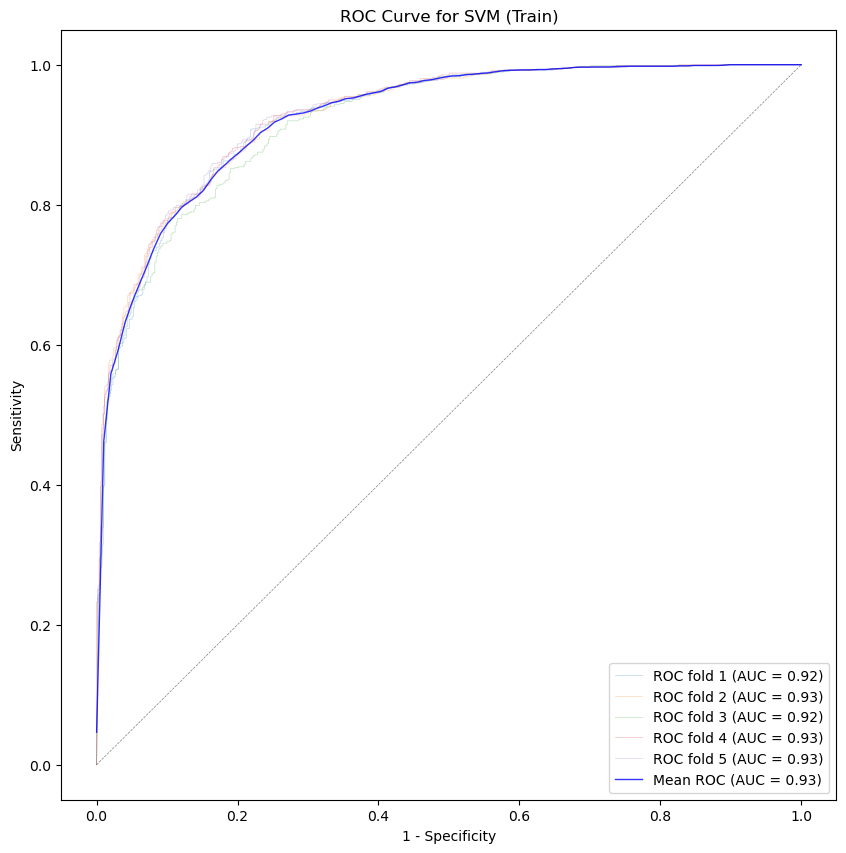

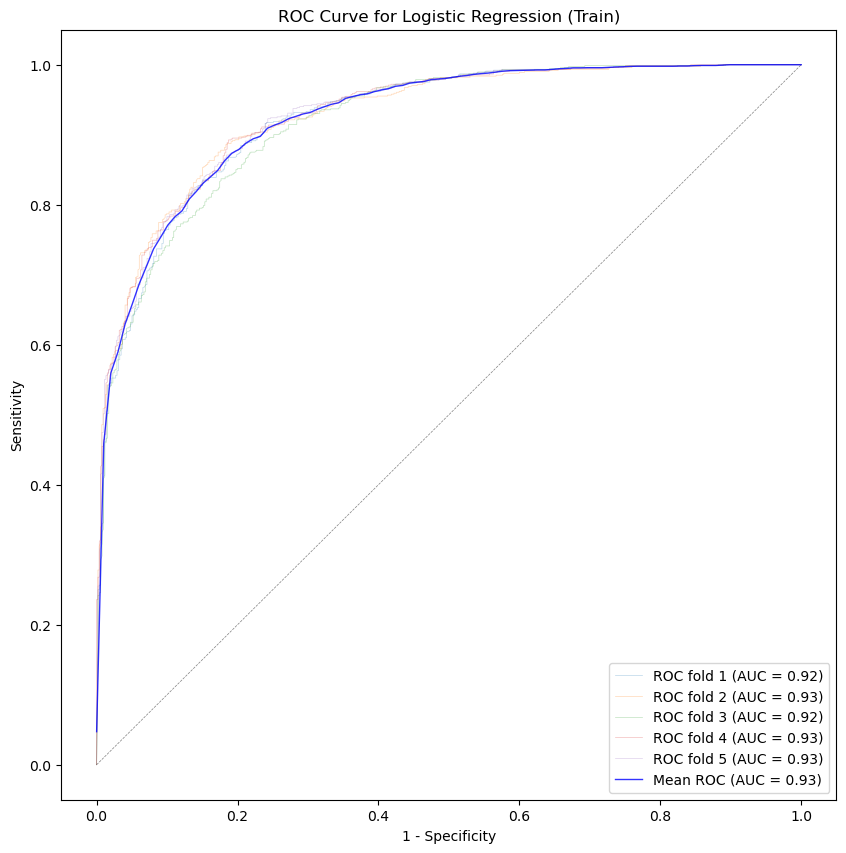

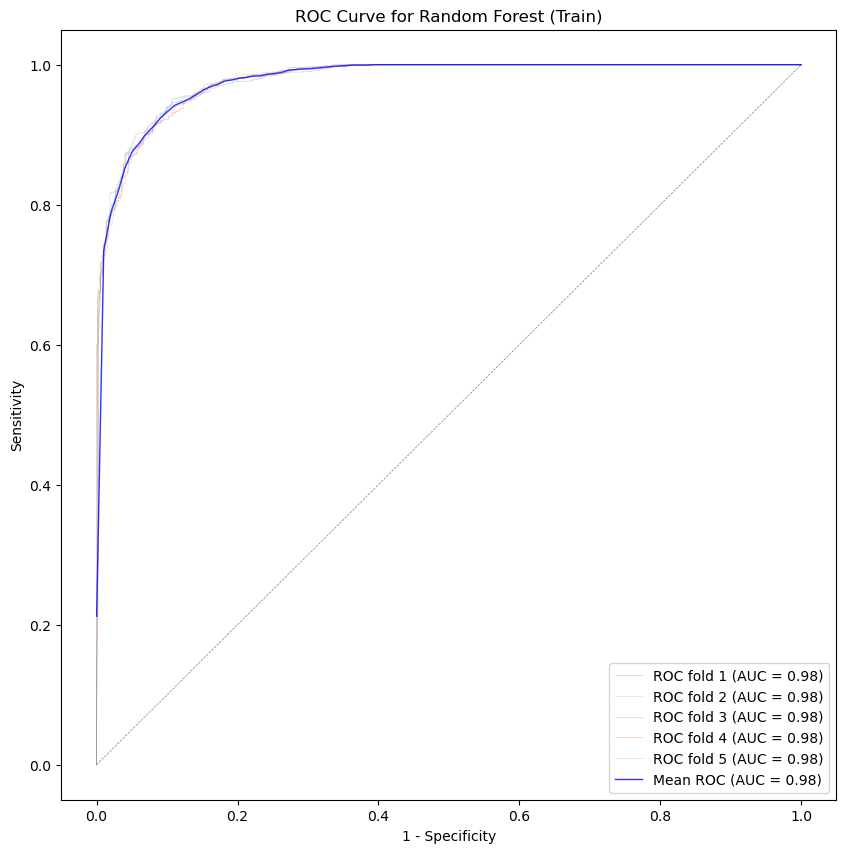

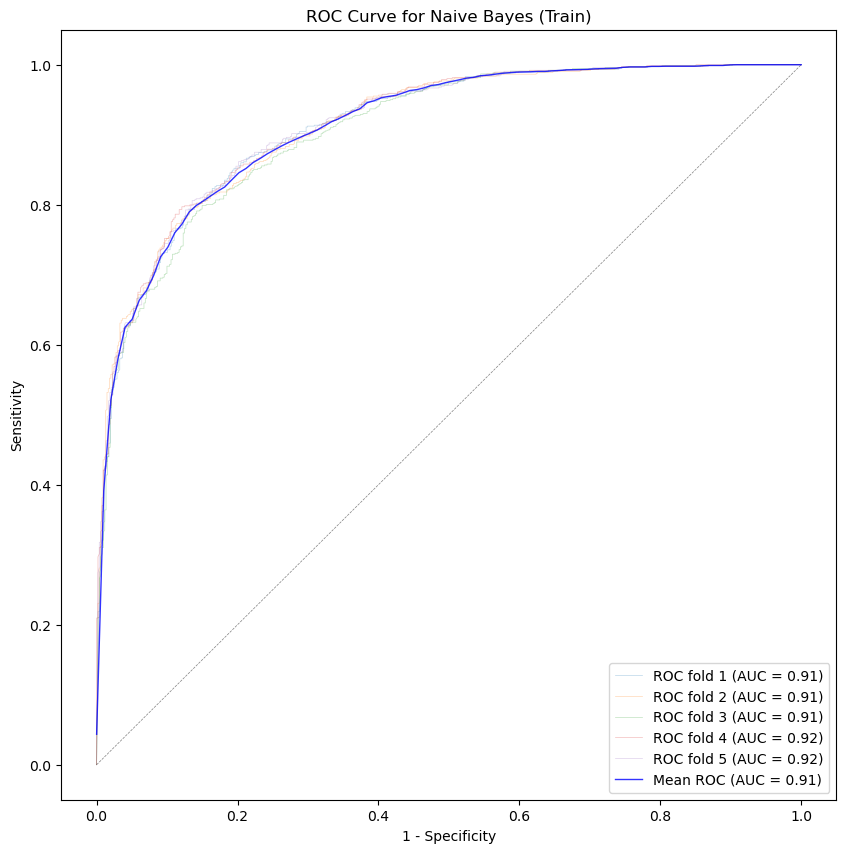

In [8]:
plot_roc_curve(
    y_test_list=y_train_list,
    model_probs_list=train_predicted_probs_list["SVM"],
    model_name="SVM (Train)",
    save_path="./fig/train_SVM.pdf"
)

plot_roc_curve(
    y_test_list=y_train_list,
    model_probs_list=train_predicted_probs_list["Logistic Regression"],
    model_name="Logistic Regression (Train)",
    save_path="./fig/train_logreg.pdf"
)


plot_roc_curve(
    y_test_list=y_train_list,
    model_probs_list=train_predicted_probs_list["Random Forest"],
    model_name="Random Forest (Train)",
    save_path="./fig/train_rf.pdf"
)


plot_roc_curve(
    y_test_list=y_train_list,
    model_probs_list=train_predicted_probs_list["Naive Bayes"],
    model_name="Naive Bayes (Train)",
    save_path="./fig/train_NB.pdf"
)

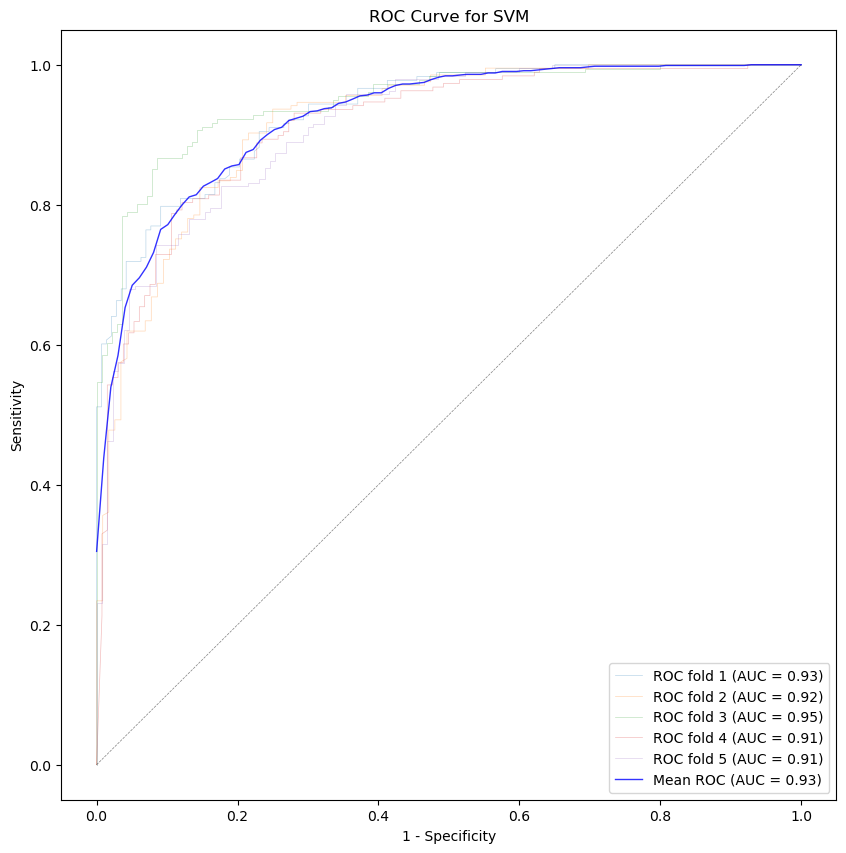

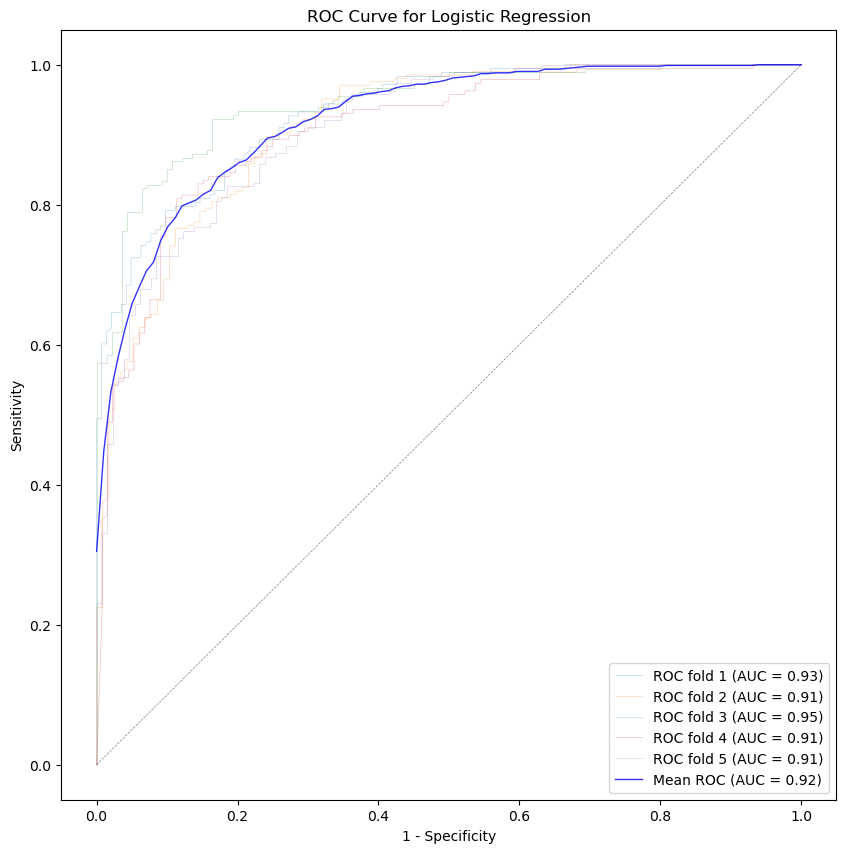

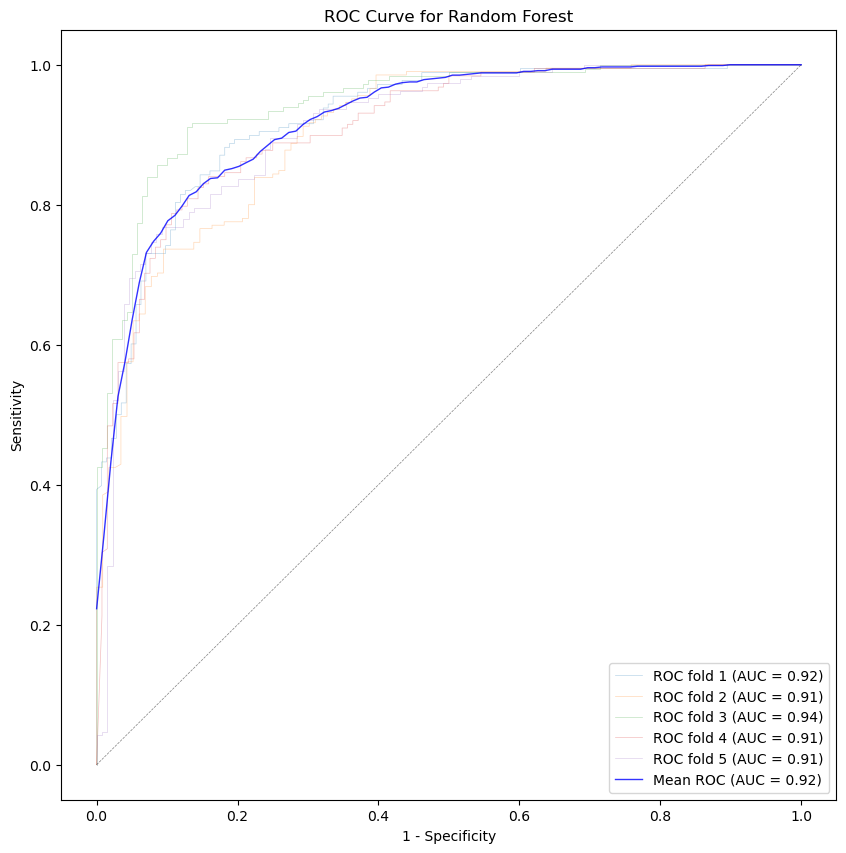

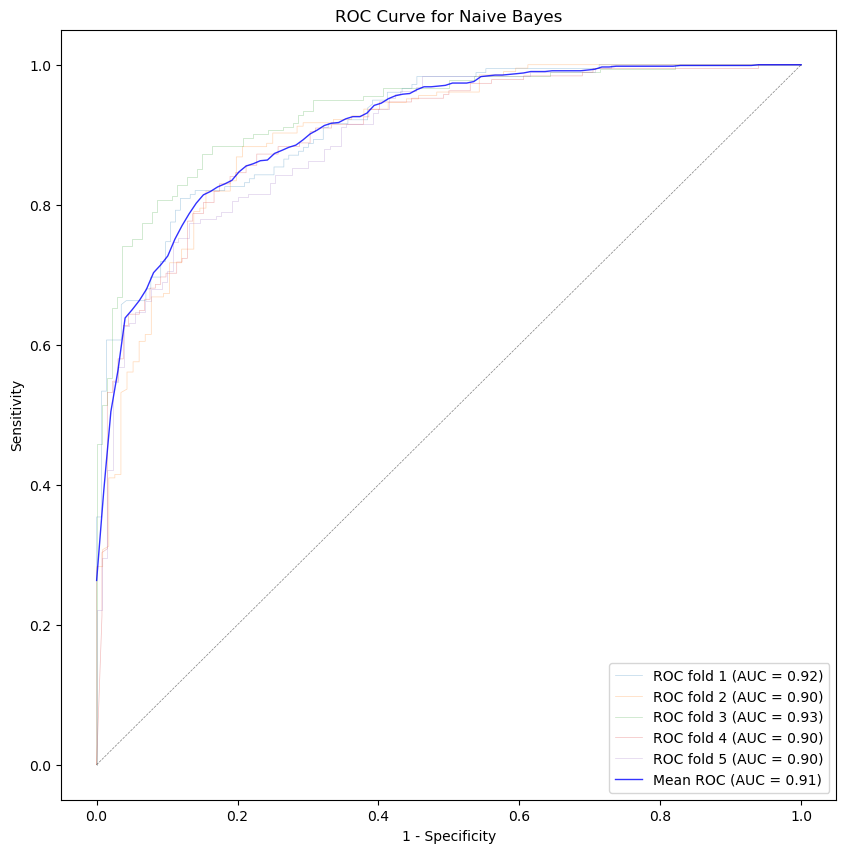

In [9]:
plot_roc_curve(y_test_list, predicted_probs_list["SVM"], "SVM", save_path='./fig/test_SVM.pdf')
plot_roc_curve(y_test_list, predicted_probs_list["Logistic Regression"], "Logistic Regression", save_path='./fig/test_logreg.pdf')
plot_roc_curve(y_test_list,  predicted_probs_list["Random Forest"], "Random Forest", save_path='./fig/test_rf.pdf')
plot_roc_curve(y_test_list,  predicted_probs_list["Naive Bayes"], "Naive Bayes", save_path='./fig/test_NB.pdf')

ExactExplainer explainer: 321it [00:20,  8.98it/s]                              


SHAP Plot for SVM


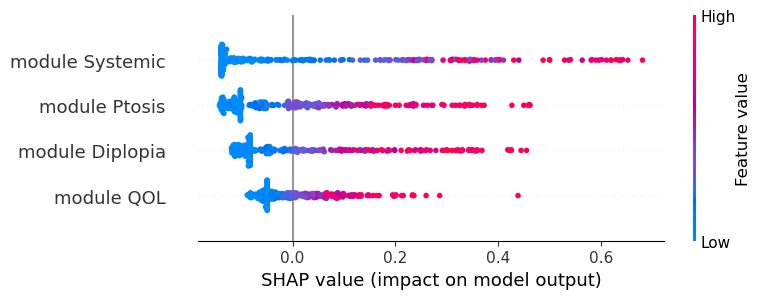

SHAP Plot for Logistic Regression


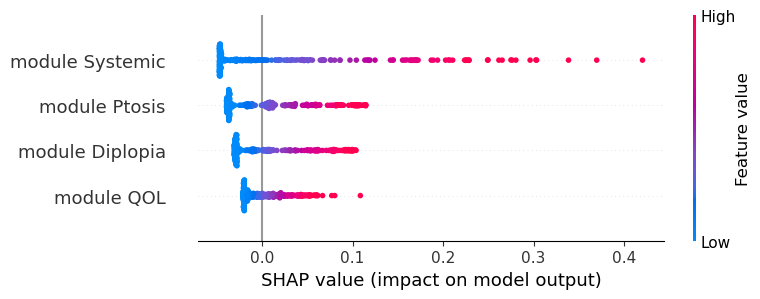

SHAP Plot for Random Forest


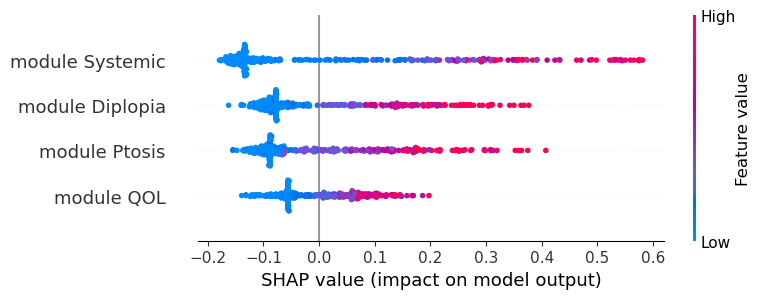

SHAP Plot for Naive Bayes


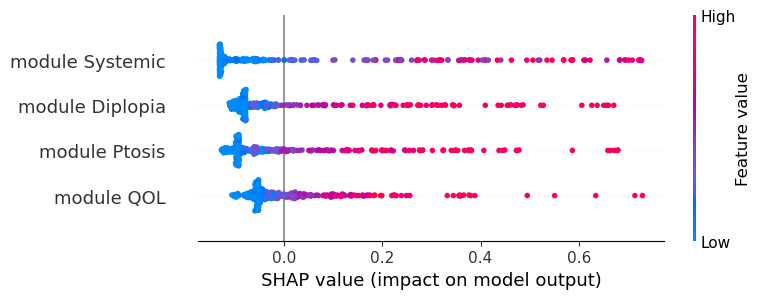

In [10]:
import numpy as np
import shap
import matplotlib.pyplot as plt

shap_values_accumulated = {
    "SVM": [],
    "Logistic Regression": [],
    "Random Forest": [],
    "Naive Bayes": []
}

def calculate_and_accumulate_shap(model, X_train, X_test, model_name):
    explainer = shap.Explainer(model.predict_proba, X_train)
    shap_values = explainer(X_test)
    shap_values_accumulated[model_name].append(shap_values.values[:, :, 0])
    return shap_values.data

def plot_average_shap(shap_values_list, feature_data, model_name, feature_names=None):
    shap_values_mean = np.mean(np.array(shap_values_list), axis=0)
    print(f"SHAP Plot for {model_name}")
    shap.summary_plot(shap_values_mean, feature_data, feature_names=feature_names)
    plt.show()

feature_data = None
for model_name, model in tuned_models.items():
    if hasattr(model, "predict_proba"):
        feature_data = calculate_and_accumulate_shap(model, X_train, X_test, model_name)

for model_name, shap_values_list in shap_values_accumulated.items():
    if shap_values_list:
        plot_average_shap(
            shap_values_list,
            feature_data,
            model_name,
            feature_names=X_train.columns if hasattr(X_train, 'columns') else None
        )

In [11]:
def save_model(model, filename):
    with open(filename, 'wb') as file:
        pickle.dump(model, file)

In [12]:
def save_all_fold_models(all_models, base_path='./out/'):
    """全foldのモデルを保存"""
    for model_name, models_list in all_models.items():
        for fold_idx, model in enumerate(models_list):
            filename = f"{base_path}{model_name.lower().replace(' ', '_')}_fold_{fold_idx}.pkl"
            with open(filename, 'wb') as file:
                pickle.dump(model, file)
    
    # モデル構造情報も保存
    with open(f"{base_path}all_fold_models_info.pkl", 'wb') as file:
        model_info = {
            'model_names': list(all_models.keys()),
            'num_folds': len(next(iter(all_models.values())))
        }
        pickle.dump(model_info, file)
    
    print(f"全foldモデル保存完了:")
    for model_name, models_list in all_models.items():
        print(f"  {model_name}: {len(models_list)}個のfoldモデル")

# ===== 全foldのモデルを保存 =====
save_all_fold_models(all_fold_models)

全foldモデル保存完了:
  SVM: 5個のfoldモデル
  Logistic Regression: 5個のfoldモデル
  Random Forest: 5個のfoldモデル
  Naive Bayes: 5個のfoldモデル


In [13]:
def save_to_pickle(data, filename):
    with open(filename, 'wb') as f:
        pickle.dump(data, f)

In [14]:
predicted_probs_files = {
    'svm': predicted_probs_list["SVM"],
    'logreg': predicted_probs_list["Logistic Regression"],
    'rf': predicted_probs_list['Random Forest'],
    'nb': predicted_probs_list['Naive Bayes']
}

for model_name, probs_list in predicted_probs_files.items():
    save_to_pickle(probs_list, f'./out/predicted_probs_{model_name}_list.pkl')

# step3. Ensemble predictions

In [15]:
from sklearn.metrics import accuracy_score

In [16]:
def load_from_pickle(filename):
    with open(filename, 'rb') as f:
        return pickle.load(f)

def load_model(filename):
    with open(filename, 'rb') as file:
        return pickle.load(file)

In [17]:
X_train_list = load_from_pickle('./out/X_train_list.pkl')
y_train_list = load_from_pickle('./out/y_train_list.pkl')
X_test_list = load_from_pickle('./out/X_test_list.pkl')
y_test_list = load_from_pickle('./out/y_test_list.pkl')

In [18]:
import pickle
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

def load_all_fold_models(base_path='./out/'):
    with open(f"{base_path}all_fold_models_info.pkl", 'rb') as file:
        model_info = pickle.load(file)

    all_models = {}
    for model_name in model_info['model_names']:
        all_models[model_name] = []
        for fold_idx in range(model_info['num_folds']):
            filename = f"{base_path}{model_name.lower().replace(' ', '_')}_fold_{fold_idx}.pkl"
            with open(filename, 'rb') as file:
                model = pickle.load(file)
                all_models[model_name].append(model)

    return all_models

# モデルとデータの読み込み（既に y_test_list, X_test_list が存在する前提）
all_fold_models_loaded = load_all_fold_models()

# 結果格納用
per_fold_auc = []

for fold_idx in range(len(y_test_list)):
    y_test = y_test_list[fold_idx]
    X_test = X_test_list[fold_idx]
    
    fold_result = {"Fold": fold_idx + 1}
    preds_dict = {}
    probs_dict = {}
    
    # 各モデルのAUC
    for model_name in ["SVM", "Logistic Regression", "Random Forest", "Naive Bayes"]:
        model = all_fold_models_loaded[model_name][fold_idx]
        probs = model.predict_proba(X_test)[:, 1]
        preds = (probs >= 0.5).astype(int)

        auc_val = roc_auc_score(y_test, probs)
        fold_result[model_name] = auc_val

        probs_dict[model_name] = probs
        preds_dict[model_name] = preds

    # 多数決アンサンブル
    pred_df = pd.DataFrame(preds_dict)
    majority_vote_preds = (pred_df.sum(axis=1) >= 2).astype(int)
    avg_proba = np.mean(np.array(list(probs_dict.values())), axis=0)
    ensemble_auc = roc_auc_score(y_test, avg_proba)
    fold_result["Ensemble Majority Vote"] = ensemble_auc

    per_fold_auc.append(fold_result)

# 結果表示
auc_df = pd.DataFrame(per_fold_auc)
print("\n=== AUC per fold ===")
print(auc_df.to_string(index=False))

# 平均 ± SD
print("\n=== Mean ± SD AUC ===")
for col in ["SVM", "Logistic Regression", "Random Forest", "Naive Bayes", "Ensemble Majority Vote"]:
    mean = auc_df[col].mean()
    std = auc_df[col].std()
    print(f"{col}: {mean:.3f} ± {std:.3f}")


=== AUC per fold ===
 Fold      SVM  Logistic Regression  Random Forest  Naive Bayes  Ensemble Majority Vote
    1 0.936581             0.935536       0.973945     0.921836                0.951326
    2 0.928805             0.928047       0.965919     0.909650                0.941935
    3 0.940402             0.941853       0.977964     0.928213                0.953835
    4 0.901537             0.895405       0.950948     0.890468                0.920409
    5 0.925506             0.924470       0.965560     0.908903                0.937570

=== Mean ± SD AUC ===
SVM: 0.927 ± 0.015
Logistic Regression: 0.925 ± 0.018
Random Forest: 0.967 ± 0.010
Naive Bayes: 0.912 ± 0.014
Ensemble Majority Vote: 0.941 ± 0.013


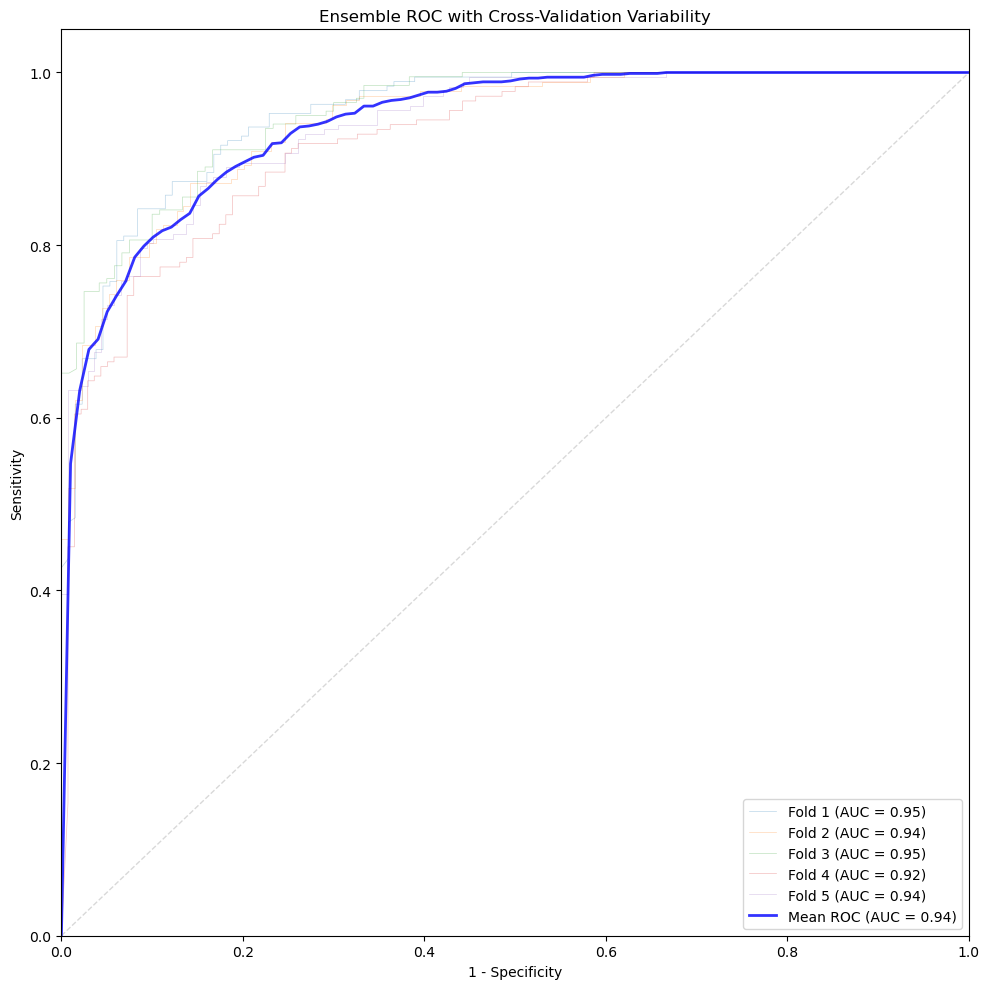

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 10))

mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []

for fold_idx in range(5):
    y_test = y_test_list[fold_idx]

    # 平均確率を使ったensemble
    probs_list = []
    for model_name in ["SVM", "Logistic Regression", "Random Forest", "Naive Bayes"]:
        model = all_fold_models_loaded[model_name][fold_idx]
        probs = model.predict_proba(X_test_list[fold_idx])[:, 1]
        probs_list.append(probs)
    avg_probs = np.mean(probs_list, axis=0)

    fpr, tpr, _ = roc_curve(y_test, avg_probs)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    # 補間して格納
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

    plt.plot(fpr, tpr, lw=0.5, alpha=0.3, label=f'Fold {fold_idx + 1} (AUC = {roc_auc:.2f})')

# 平均ROC
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean(aucs)

plt.plot(mean_fpr, mean_tpr, color='blue',
         label=f'Mean ROC (AUC = {mean_auc:.2f})',
         lw=2, alpha=0.8)

# その他装飾
plt.plot([0, 1], [0, 1], linestyle='--', lw=1, color='gray', alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('Ensemble ROC with Cross-Validation Variability')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# step4. validation

In [20]:
# Step 1: Load the original data and H matrix
import numpy as np
import pandas as pd
import pickle
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, precision_score, recall_score, f1_score, matthews_corrcoef
import matplotlib.pyplot as plt

# Load the original dataset and H matrix
original_df_path = "./data/df_4th.csv"
validation_df_path = "./data/df_3rd.csv"
df_ori = pd.read_csv(original_df_path, index_col=0)
df_val_ori = pd.read_csv(validation_df_path, index_col=0, encoding='cp1252')

with open('./out/H_matrix.pkl', 'rb') as file:
    H = pickle.load(file)

# Define constants
max_iter = 100

# Prepare scaled data
df_names = [
    "MGC_ptosis", "MGC_diplopia", "MGC_eyelid_closure", "MGC_speech", "MGC_chewing",
    "MGC_swallowing", "MGC_respiration", "MGC_neck", "MGC_upper_limb", "MGC_lower_limb",
    "MGADL_speech", "MGADL_chewing", "MGADL_swallowing", "MGADL_respiration",
    "MGADL_toothbrushing", "MGADL_getting_up", "MGADL_diplopia", "MGADL_ptosis",
    "MGQOL1_dissatisfaction", "MGQOL2_seeing", "MGQOL3_eating",
    "MGQOL4_social_activity_restriction", "MGQOL5_hobby_entertainment", "MGQOL6_family_role",
    "MGQOL7_behavior_modification", "MGQOL8_work_impact", "MGQOL9_speaking",
    "MGQOL10_driving", "MGQOL11_feeling_down", "MGQOL12_walking", "MGQOL13_quick_action",
    "MGQOL14_mental_crushing", "MGQOL15_dressing"
]

df = df_ori[df_names]
df_val = df_val_ori[df_names]
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
df_val_scaled = pd.DataFrame(scaler.transform(df_val), columns=df_val.columns)

# Load all fold models
all_fold_models_validation = load_all_fold_models()
num_folds = len(all_fold_models_validation['SVM'])

# Load optimal cutoff values
with open('./out/optimal_cutoffs.pkl', 'rb') as f:
    optimal_cutoffs = pickle.load(f)

# Store results
true_labels_by_fold = [[] for _ in range(num_folds)]
probabilities_by_fold = {
    "SVM": [[] for _ in range(num_folds)],
    "Logistic Regression": [[] for _ in range(num_folds)],
    "Random Forest": [[] for _ in range(num_folds)],
    "Naive Bayes": [[] for _ in range(num_folds)]
}

W_validation_list = []

print(f"=== : 全{num_folds}foldアンサンブル ===")

for i in range(df_val_scaled.shape[0]):
    if i % 50 == 0:
        print(f"処理中: {i}/{df_val_scaled.shape[0]}")

    validation_sample = df_val_scaled.iloc[i:i+1]
    concatenated_df_scaled = pd.concat([df_scaled, validation_sample], axis=0)
    np.random.seed(0)

    W_concatenated = np.random.rand(concatenated_df_scaled.shape[0], H.shape[0])
    for _ in range(max_iter):
        numer = concatenated_df_scaled.values @ H.T
        denom = W_concatenated @ (H @ H.T)
        denom = np.where(denom == 0, 1, denom)
        W_concatenated *= numer / denom

    W_validation_sample = W_concatenated[-1:, :]
    W_validation_list.append(W_validation_sample.flatten())
    X_validation = pd.DataFrame(W_validation_sample, columns=["module QOL", "module Diplopia", "module Ptosis", "module Systemic"])
    y_val = df_val_ori["MMorbetter"].iloc[i]

    for fold_idx in range(num_folds):
        for model_name in ["SVM", "Logistic Regression", "Random Forest", "Naive Bayes"]:
            model = all_fold_models_validation[model_name][fold_idx]
            prob = model.predict_proba(X_validation)[:, 1][0]
            probabilities_by_fold[model_name][fold_idx].append(prob)

        true_labels_by_fold[fold_idx].append(y_val)

# Plotting function
def plot_roc_curve(y_test_list, model_probs_list, model_name, save_path=None):
    plt.figure(figsize=(10, 10))
    mean_fpr = np.linspace(0, 1, 100)
    mean_tpr = 0.0

    for i, (y_test, probas) in enumerate(zip(y_test_list, model_probs_list)):
        fpr, tpr, _ = roc_curve(y_test, probas)
        mean_tpr += np.interp(mean_fpr, fpr, tpr)
        plt.plot(fpr, tpr, lw=0.5, alpha=0.3, label=f'Fold {i+1} (AUC = {auc(fpr, tpr):.2f})')

    mean_tpr /= len(y_test_list)
    plt.plot(mean_fpr, mean_tpr, color='blue', lw=1, label=f'Mean ROC (AUC = {auc(mean_fpr, mean_tpr):.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', lw=0.5, color='black', alpha=0.5)
    plt.xlabel('1 - Specificity')
    plt.ylabel('Sensitivity')
    plt.title(f'ROC Curve for {model_name}')
    plt.legend(loc='lower right')
    
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight')
    
    plt.show()

=== : 全5foldアンサンブル ===
処理中: 0/414
処理中: 50/414
処理中: 100/414
処理中: 150/414
処理中: 200/414
処理中: 250/414
処理中: 300/414
処理中: 350/414
処理中: 400/414


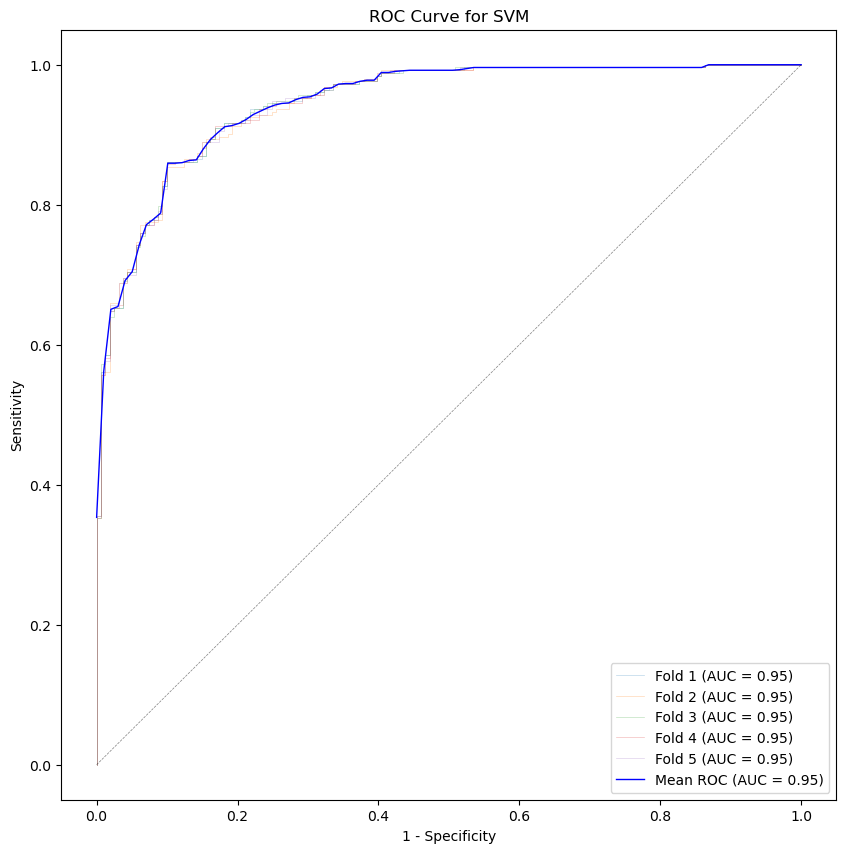

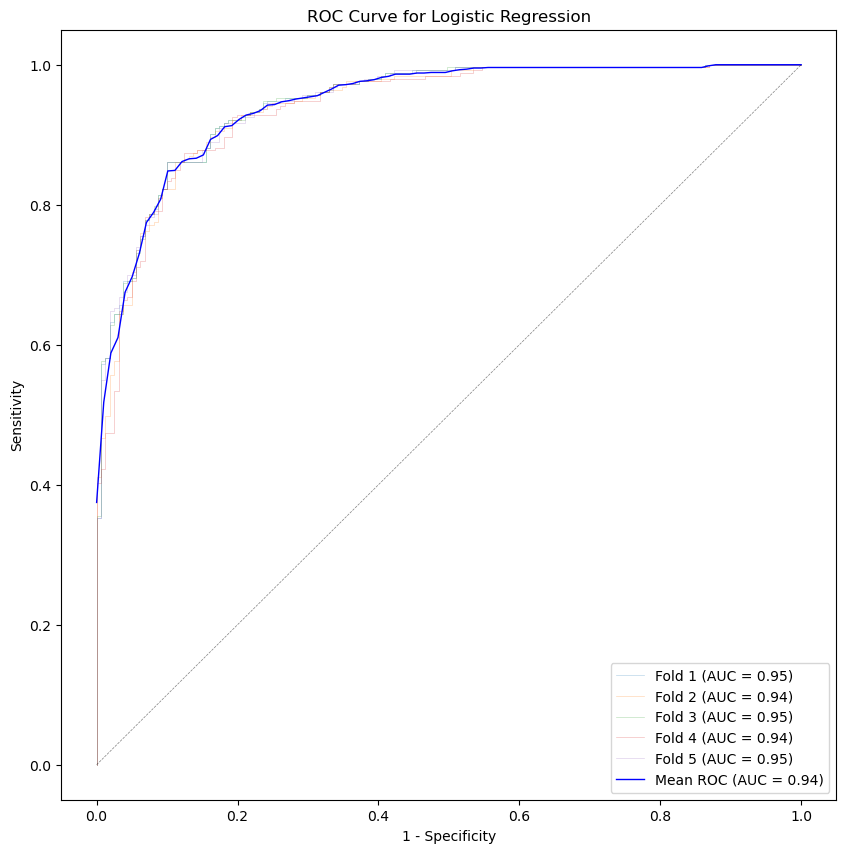

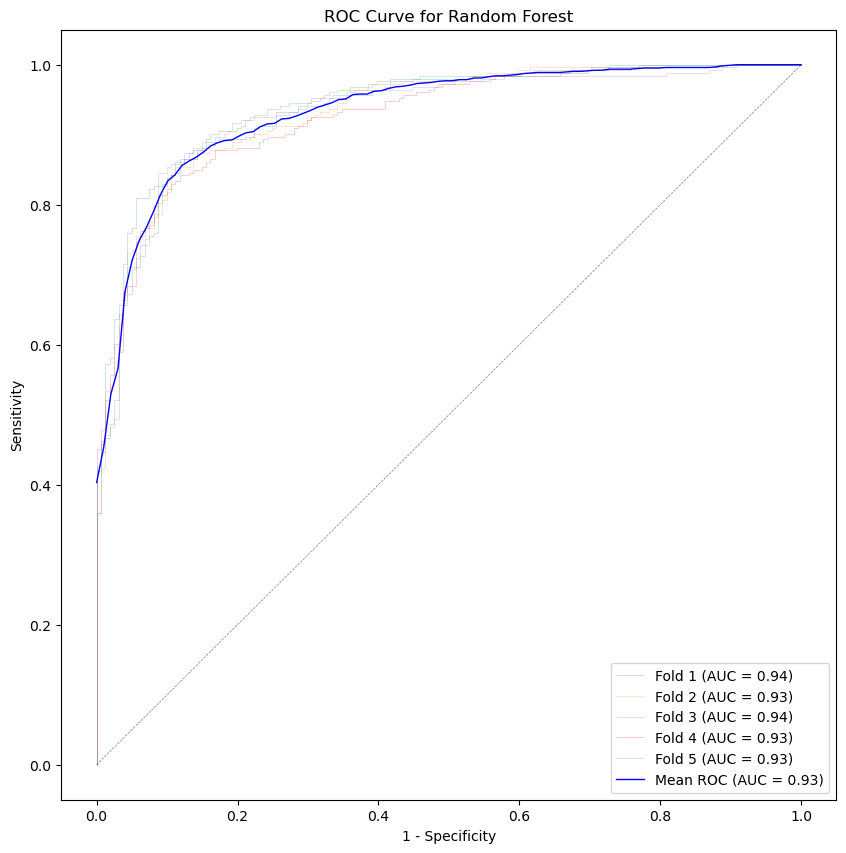

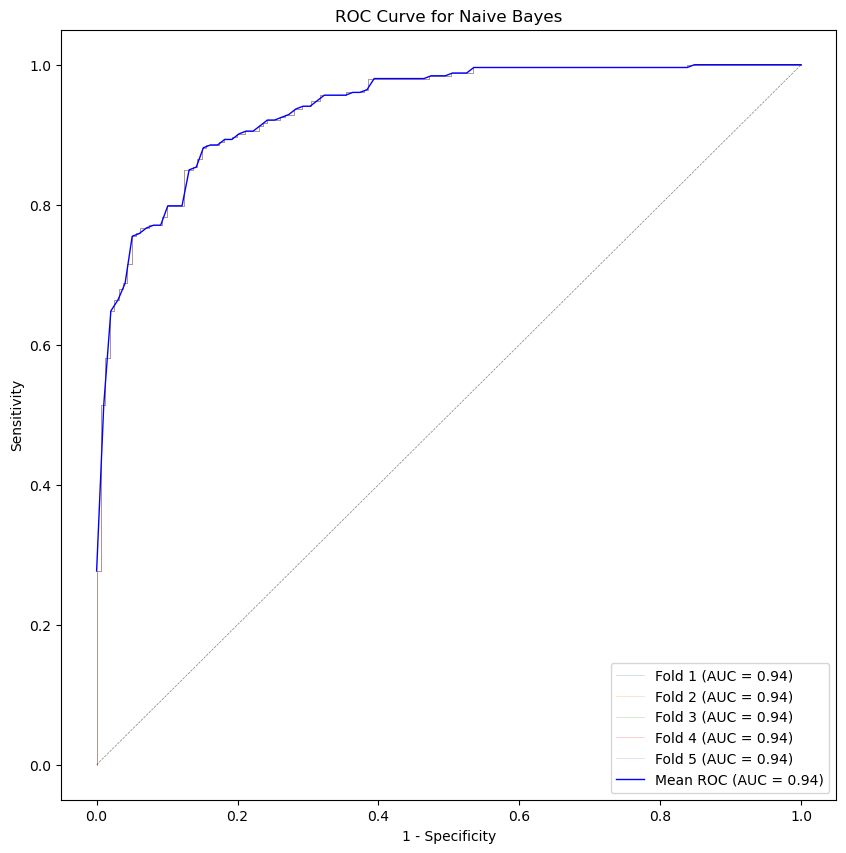

In [21]:
plot_roc_curve(true_labels_by_fold, probabilities_by_fold["SVM"], model_name="SVM", save_path='./fig/val_SVM.pdf')
plot_roc_curve(true_labels_by_fold, probabilities_by_fold["Logistic Regression"], model_name="Logistic Regression", save_path='./fig/val_logreg.pdf')
plot_roc_curve(true_labels_by_fold, probabilities_by_fold["Random Forest"], model_name="Random Forest", save_path='./fig/val_rf.pdf')
plot_roc_curve(true_labels_by_fold, probabilities_by_fold["Naive Bayes"], model_name="Naive Bayes", save_path='./fig/val_NB.pdf')

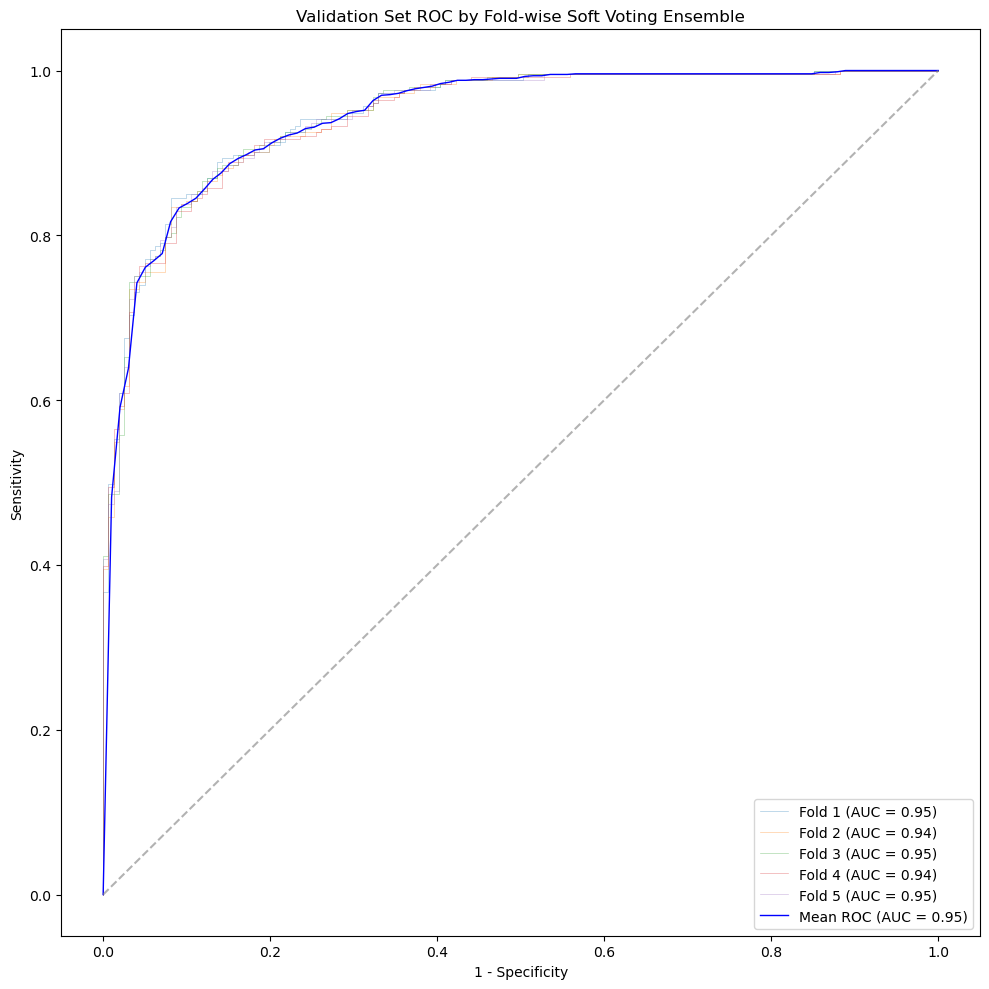

In [22]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 必要なデータ
X_val_W = pd.DataFrame(W_validation_list, columns=["module QOL", "module Diplopia", "module Ptosis", "module Systemic"])

plt.figure(figsize=(10, 10))

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

true_labels = df_val_ori["MMorbetter"].tolist()

for fold_idx in range(5):
    fold_probs = []

    for i in range(X_val_W.shape[0]):
        x_sample = X_val_W.iloc[i:i+1]

        probs = []
        for model_name in ["SVM", "Logistic Regression", "Random Forest", "Naive Bayes"]:
            model = all_fold_models_validation[model_name][fold_idx]
            prob = model.predict_proba(x_sample)[:, 1][0]
            probs.append(prob)

        # ソフトボーティング（確率の平均）
        soft_vote_prob = np.mean(probs)
        fold_probs.append(soft_vote_prob)

    # foldごとのROC
    fpr, tpr, _ = roc_curve(true_labels, fold_probs)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

    fold_auc = auc(fpr, tpr)
    aucs.append(fold_auc)

    plt.plot(fpr, tpr, lw=0.5, alpha=0.4, label=f"Fold {fold_idx + 1} (AUC = {fold_auc:.2f})")

# 平均ROC
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean(aucs)

plt.plot(mean_fpr, mean_tpr, color='blue', lw=1, label=f"Mean ROC (AUC = {mean_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.6)
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('Validation Set ROC by Fold-wise Soft Voting Ensemble')
plt.legend(loc='lower right')
plt.tight_layout()

plt.savefig("./fig/fig5.pdf", format='pdf')

plt.show()

In [23]:
from sklearn.metrics import (
    roc_curve, roc_auc_score, confusion_matrix,
    accuracy_score, precision_score, f1_score, matthews_corrcoef
)
import numpy as np
import scipy.stats as st

# 指標格納
auc_list = []
sens_list = []
spec_list = []
acc_list = []
prec_list = []
f1_list = []
mcc_list = []

for fold_idx in range(5):
    fold_probs = []
    for i in range(X_val_W.shape[0]):
        x_sample = X_val_W.iloc[i:i+1]
        probs = []
        for model_name in ["SVM", "Logistic Regression", "Random Forest", "Naive Bayes"]:
            model = all_fold_models_validation[model_name][fold_idx]
            prob = model.predict_proba(x_sample)[:, 1][0]
            probs.append(prob)
        fold_probs.append(np.mean(probs))

    y_true = np.array(true_labels)
    y_score = np.array(fold_probs)

    # === AUC ===
    auc = roc_auc_score(y_true, y_score)
    auc_list.append(auc)

    # === Youden indexで最適cutoff ===
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    youden_index = tpr - fpr
    best_threshold = thresholds[np.argmax(youden_index)]

    y_pred = (y_score >= best_threshold).astype(int)

    # === confusion matrixから Sens/Spec ===
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    sens_list.append(sens)
    spec_list.append(spec)

    # === 他指標 ===
    acc_list.append(accuracy_score(y_true, y_pred))
    prec_list.append(precision_score(y_true, y_pred, zero_division=0))
    f1_list.append(f1_score(y_true, y_pred, zero_division=0))
    mcc_list.append(matthews_corrcoef(y_true, y_pred))

# === CI関数 ===
def mean_ci(data):
    data = np.array(data)
    mean = np.mean(data)
    sem = st.sem(data, nan_policy="omit")
    ci = st.t.interval(0.95, len(data)-1, loc=mean, scale=sem)
    return mean, ci

# === 出力 ===
metrics = {
    "AUROC": auc_list,
    "Accuracy": acc_list,
    "Sensitivity": sens_list,
    "Specificity": spec_list,
    "Precision": prec_list,
    "F1 score": f1_list,
    "MCC": mcc_list
}

for name, values in metrics.items():
    mean, (ci_lower, ci_upper) = mean_ci(values)
    print(f"{name}: {mean:.2f} (95% CI: {ci_lower:.2f} - {ci_upper:.2f})")


AUROC: 0.95 (95% CI: 0.94 - 0.95)
Accuracy: 0.87 (95% CI: 0.86 - 0.88)
Sensitivity: 0.85 (95% CI: 0.83 - 0.88)
Specificity: 0.90 (95% CI: 0.87 - 0.93)
Precision: 0.93 (95% CI: 0.91 - 0.95)
F1 score: 0.89 (95% CI: 0.88 - 0.90)
MCC: 0.74 (95% CI: 0.73 - 0.75)


# socre based judgementとの比較

In [24]:
# MGADLスコア合計
df_val_ori["MGADL"] = df_val_ori[[
    "MGADL_speech", "MGADL_chewing", "MGADL_swallowing", "MGADL_respiration",
    "MGADL_toothbrushing", "MGADL_getting_up", "MGADL_diplopia", "MGADL_ptosis"
]].sum(axis=1)

# QMGスコア合計（名称がMGC_〜でもQMGとして使っているならこれでOK）
df_val_ori["QMG"] = df_val_ori[[
    "MGC_ptosis", "MGC_diplopia", "MGC_eyelid_closure", "MGC_speech", "MGC_chewing", 
    "MGC_swallowing", "MGC_respiration", "MGC_neck", "MGC_upper_limb", "MGC_lower_limb"
]].sum(axis=1)

# MGCスコア合計（上と重複する場合はこの項目は省略可）
df_val_ori["MGC"] = df_val_ori["QMG"]  # 同じなら再利用

# MGQOL15スコア合計
df_val_ori["MGQOL15"] = df_val_ori[[
    "MGQOL1_dissatisfaction", "MGQOL2_seeing", "MGQOL3_eating", "MGQOL4_social_activity_restriction",
    "MGQOL5_hobby_entertainment", "MGQOL6_family_role", "MGQOL7_behavior_modification",
    "MGQOL8_work_impact", "MGQOL9_speaking", "MGQOL10_driving", "MGQOL11_feeling_down",
    "MGQOL12_walking", "MGQOL13_quick_action", "MGQOL14_mental_crushing", "MGQOL15_dressing"
]].sum(axis=1)

In [25]:
# MGADL単独での判定（PASS閾値: ≦ 2）
df_val_ori["MM_PASS_MGADL_only"] = (df_val_ori["MGADL"] <= 2).astype(int)

# MGC単独での判定（PASS閾値: ≦ 3）
df_val_ori["MM_PASS_MGC_only"] = (df_val_ori["MGC"] <= 3).astype(int)

# MGQOL15単独での判定（PASS閾値: ≦ 7）
df_val_ori["MM_PASS_MGQOL_only"] = (df_val_ori["MGQOL15"] <= 7).astype(int)

In [26]:
soft_vote_binary = [int(p >= 0.7) for p in fold_probs]

In [27]:
majority_vote = []

for i in range(X_val_W.shape[0]):
    x_sample = X_val_W.iloc[i:i+1]

    fold_votes = []

    for fold_idx in range(5):
        # fold内の4モデルの予測（0 or 1）を収集
        votes = []
        for model_name in ["SVM", "Logistic Regression", "Random Forest", "Naive Bayes"]:
            model = all_fold_models_validation[model_name][fold_idx]
            pred = model.predict(x_sample)[0]
            votes.append(pred)

        # fold内で 3/4 以上が「1」なら 1 とする（それ以外は 0）
        fold_vote = int(np.sum(votes) >= 4)
        fold_votes.append(fold_vote)

    # 5fold のうち多数が 1 なら最終的に 1
    majority_vote.append(int(np.sum(fold_votes) >= 5))


In [28]:
from sklearn.metrics import confusion_matrix, accuracy_score

def evaluate_rule_based(name, preds):
    cm = confusion_matrix(true_labels, preds)
    acc = accuracy_score(true_labels, preds)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    print(f"[{name}]")
    print("Confusion Matrix:\n", cm)
    print(f"Accuracy: {acc:.2f}")
    print(f"Sensitivity : {sensitivity:.2f}")
    print(f"Specificity: {specificity:.2f}\n")

# 比較（モデル vs ルールベース）
evaluate_rule_based("PASS: MGADL only", df_val_ori["MM_PASS_MGADL_only"])
evaluate_rule_based("PASS: MGC only", df_val_ori["MM_PASS_MGC_only"])
evaluate_rule_based("PASS: MGQOL15 only", df_val_ori["MM_PASS_MGQOL_only"])
evaluate_rule_based("Model", soft_vote_binary)
evaluate_rule_based("Model_vote", majority_vote)

[PASS: MGADL only]
Confusion Matrix:
 [[129  32]
 [ 21 232]]
Accuracy: 0.87
Sensitivity : 0.92
Specificity: 0.80

[PASS: MGC only]
Confusion Matrix:
 [[120  41]
 [ 24 229]]
Accuracy: 0.84
Sensitivity : 0.91
Specificity: 0.75

[PASS: MGQOL15 only]
Confusion Matrix:
 [[135  26]
 [ 87 166]]
Accuracy: 0.73
Sensitivity : 0.66
Specificity: 0.84

[Model]
Confusion Matrix:
 [[147  14]
 [ 42 211]]
Accuracy: 0.86
Sensitivity : 0.83
Specificity: 0.91

[Model_vote]
Confusion Matrix:
 [[161   0]
 [253   0]]
Accuracy: 0.39
Sensitivity : 0.00
Specificity: 1.00



In [29]:
from sklearn.metrics import roc_curve, auc

true_labels = df_val_ori["MMorbetter"]

# それぞれのルールベース予測（0/1）
mgadl_pred = df_val_ori["MM_PASS_MGADL_only"]
mgc_pred = df_val_ori["MM_PASS_MGC_only"]
mgqol_pred = df_val_ori["MM_PASS_MGQOL_only"]

# AUCを計算（0/1でも計算可能）
for name, pred in [("MGADL", mgadl_pred), ("MGC", mgc_pred), ("MGQOL15", mgqol_pred)]:
    fpr, tpr, _ = roc_curve(true_labels, pred)
    score = auc(fpr, tpr)
    print(f"{name} AUC = {score:.2f}")


MGADL AUC = 0.86
MGC AUC = 0.83
MGQOL15 AUC = 0.75


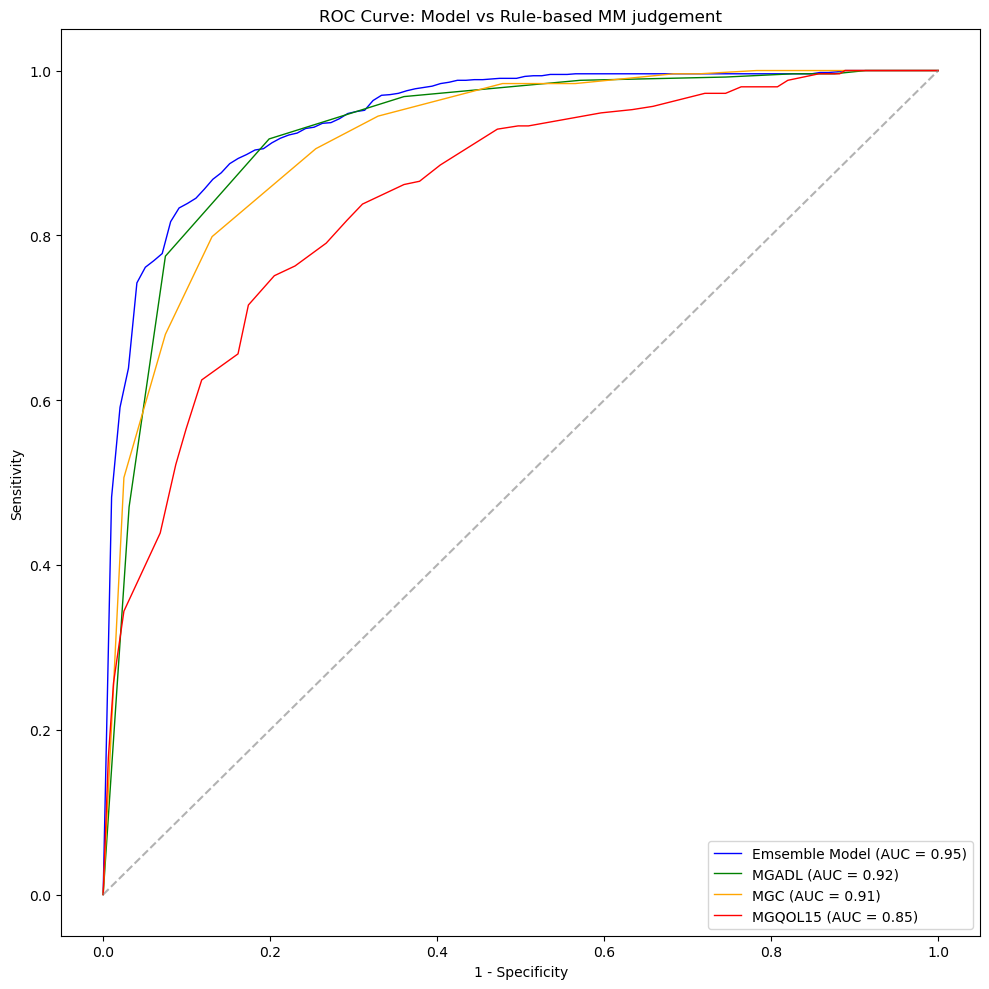

In [30]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# === データ準備 ===
X_val_W = pd.DataFrame(W_validation_list, columns=["module QOL", "module Diplopia", "module Ptosis", "module Systemic"])
true_labels = df_val_ori["MMorbetter"].tolist()

plt.figure(figsize=(10, 10))

# ==== モデル（Soft Voting 平均） ====
mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []

for fold_idx in range(5):
    fold_probs = []
    for i in range(X_val_W.shape[0]):
        x_sample = X_val_W.iloc[i:i+1]
        probs = [
            all_fold_models_validation[model_name][fold_idx].predict_proba(x_sample)[:, 1][0]
            for model_name in ["SVM", "Logistic Regression", "Random Forest", "Naive Bayes"]
        ]
        soft_vote_prob = np.mean(probs)
        fold_probs.append(soft_vote_prob)

    fpr, tpr, _ = roc_curve(true_labels, fold_probs)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(auc(fpr, tpr))

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean(aucs)
plt.plot(mean_fpr, mean_tpr, linestyle='-', color='blue', lw=1, label=f"Emsemble Model (AUC = {mean_auc:.2f})")

# ==== ルールベース（連続スコア） ====
rule_defs_continuous = [
    ("MGADL", -df_val_ori["MGADL"]),
    ("MGC", -df_val_ori["MGC"]),
    ("MGQOL15", -df_val_ori["MGQOL15"]),
]
rule_colors = ["green", "orange", "red"]

for (label, score), color in zip(rule_defs_continuous, rule_colors):
    fpr, tpr, _ = roc_curve(true_labels, score)
    rule_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linestyle='-', lw=1, color=color, label=f"{label} (AUC = {rule_auc:.2f})")

# ==== 装飾 ====
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.6)
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC Curve: Model vs Rule-based MM judgement')
plt.legend(loc='lower right')
plt.tight_layout()

plt.savefig("./fig/Model vs Rule-based MM judgement.pdf", format='pdf')

plt.show()


# 症例を入力して予測

In [31]:
# セル1: 必要なライブラリ
import numpy as np
import pandas as pd
import pickle
from sklearn.preprocessing import MinMaxScaler

print("✓ ライブラリ読み込み完了")

# セル2: 項目名の定義
df_names = [
    "MGC_ptosis", "MGC_diplopia", "MGC_eyelid_closure", "MGC_speech", "MGC_chewing",
    "MGC_swallowing", "MGC_respiration", "MGC_neck", "MGC_upper_limb", "MGC_lower_limb",
    "MGADL_speech", "MGADL_chewing", "MGADL_swallowing", "MGADL_respiration",
    "MGADL_toothbrushing", "MGADL_getting_up", "MGADL_diplopia", "MGADL_ptosis",
    "MGQOL1_dissatisfaction", "MGQOL2_seeing", "MGQOL3_eating",
    "MGQOL4_social_activity_restriction", "MGQOL5_hobby_entertainment", "MGQOL6_family_role",
    "MGQOL7_behavior_modification", "MGQOL8_work_impact", "MGQOL9_speaking",
    "MGQOL10_driving", "MGQOL11_feeling_down", "MGQOL12_walking", "MGQOL13_quick_action",
    "MGQOL14_mental_crushing", "MGQOL15_dressing"
]

# セル3: 患者データ入力
patient_input = {
    # MGC 
    "MGC_ptosis": 0,
    "MGC_diplopia": 0,
    "MGC_eyelid_closure": 0,
    "MGC_speech": 0,
    "MGC_chewing": 0,
    "MGC_swallowing": 0,
    "MGC_respiration": 1,
    "MGC_neck": 1,
    "MGC_upper_limb": 0,
    "MGC_lower_limb": 0,
    # MGADL
    "MGADL_speech": 0,
    "MGADL_chewing": 0,
    "MGADL_swallowing": 0,
    "MGADL_respiration": 0,
    "MGADL_toothbrushing": 1,
    "MGADL_getting_up": 0,
    "MGADL_diplopia": 0,
    "MGADL_ptosis": 0,
    # MGQOL15r
    "MGQOL1_dissatisfaction": 0,
    "MGQOL2_seeing": 0,
    "MGQOL3_eating": 0,
    "MGQOL4_social_activity_restriction": 0,
    "MGQOL5_hobby_entertainment": 0,
    "MGQOL6_family_role": 0,
    "MGQOL7_behavior_modification": 0,
    "MGQOL8_work_impact": 0,
    "MGQOL9_speaking": 0,
    "MGQOL10_driving": 0,
    "MGQOL11_feeling_down": 0,
    "MGQOL12_walking": 0,
    "MGQOL13_quick_action": 1,
    "MGQOL14_mental_crushing": 1,
    "MGQOL15_dressing": 1
}

patient_data = pd.DataFrame([patient_input])
print("✓ データ準備完了")
display(patient_data)

✓ ライブラリ読み込み完了
✓ データ準備完了


,MGC_ptosis,MGC_diplopia,MGC_eyelid_closure,MGC_speech,MGC_chewing,MGC_swallowing,MGC_respiration,MGC_neck,MGC_upper_limb,MGC_lower_limb,...,MGQOL6_family_role,MGQOL7_behavior_modification,MGQOL8_work_impact,MGQOL9_speaking,MGQOL10_driving,MGQOL11_feeling_down,MGQOL12_walking,MGQOL13_quick_action,MGQOL14_mental_crushing,MGQOL15_dressing
0,0,0,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,1,1,1


In [32]:
# セル4: 元のコード - データ読み込み
original_df_path = "./data/df_4th.csv"
df_ori = pd.read_csv(original_df_path, index_col=0)

with open('./out/H_matrix.pkl', 'rb') as file:
    H = pickle.load(file)

max_iter = 100

df = df_ori[df_names]
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# 患者データをスケーリング（df_val_scaledの代わり）
patient_data_scaled = pd.DataFrame(scaler.transform(patient_data[df_names]), columns=df_names)

print("✓ 訓練データとH行列読み込み完了")

# セル5: モデル読み込み
def load_all_fold_models(base_path='./out/'):
    with open(f"{base_path}all_fold_models_info.pkl", 'rb') as file:
        model_info = pickle.load(file)
    all_models = {}
    for model_name in model_info['model_names']:
        all_models[model_name] = []
        for fold_idx in range(model_info['num_folds']):
            filename = f"{base_path}{model_name.lower().replace(' ', '_')}_fold_{fold_idx}.pkl"
            with open(filename, 'rb') as file:
                model = pickle.load(file)
                all_models[model_name].append(model)
    return all_models

all_fold_models_validation = load_all_fold_models()
num_folds = len(all_fold_models_validation['SVM'])

probabilities_by_fold = {
    "SVM": [[] for _ in range(num_folds)],
    "Logistic Regression": [[] for _ in range(num_folds)],
    "Random Forest": [[] for _ in range(num_folds)],
    "Naive Bayes": [[] for _ in range(num_folds)]
}

print(f"✓ モデル読み込み完了: {num_folds} folds")

# セル6: 予測実行（元のコードから該当行だけ変更）
validation_sample = patient_data_scaled.iloc[0:1]  # df_val_scaled.iloc[i:i+1] から変更
concatenated_df_scaled = pd.concat([df_scaled, validation_sample], axis=0)
np.random.seed(0)

W_concatenated = np.random.rand(concatenated_df_scaled.shape[0], H.shape[0])
for _ in range(max_iter):
    numer = concatenated_df_scaled.values @ H.T
    denom = W_concatenated @ (H @ H.T)
    denom = np.where(denom == 0, 1, denom)
    W_concatenated *= numer / denom

W_validation_sample = W_concatenated[-1:, :]
X_validation = pd.DataFrame(W_validation_sample, columns=["module QOL", "module Diplopia", "module Ptosis", "module Systemic"])

print("\nモジュールスコア:")
display(X_validation)

for fold_idx in range(num_folds):
    for model_name in ["SVM", "Logistic Regression", "Random Forest", "Naive Bayes"]:
        model = all_fold_models_validation[model_name][fold_idx]
        prob = model.predict_proba(X_validation)[:, 1][0]
        probabilities_by_fold[model_name][fold_idx].append(prob)

# セル7: 結果表示
print("\n" + "=" * 70)
print("【予測結果】")
print("=" * 70)

for model_name in ["SVM", "Logistic Regression", "Random Forest", "Naive Bayes"]:
    probs = [probabilities_by_fold[model_name][fold_idx][0] for fold_idx in range(num_folds)]
    print(f"{model_name}: {np.mean(probs):.3f}")

# アンサンブル
all_probs = []
for model_name in ["SVM", "Logistic Regression", "Random Forest", "Naive Bayes"]:
    for fold_idx in range(num_folds):
        all_probs.append(probabilities_by_fold[model_name][fold_idx][0])

ensemble_prob = np.mean(all_probs)
print(f"\nアンサンブル: {ensemble_prob:.3f} ({ensemble_prob*100:.1f}%)")
print("=" * 70)

✓ 訓練データとH行列読み込み完了
✓ モデル読み込み完了: 5 folds

モジュールスコア:


,module QOL,module Diplopia,module Ptosis,module Systemic
0,0.039138,3.201920e-12,7.823705e-40,0.028039



【予測結果】
SVM: 0.932
Logistic Regression: 0.617
Random Forest: 0.947
Naive Bayes: 0.988

アンサンブル: 0.871 (87.1%)


復元されたモジュール順序:
['module QOL', 'module Diplopia', 'module Ptosis', 'module Systemic']

✓ 図を保存: ./fig/prediction_radar.pdf


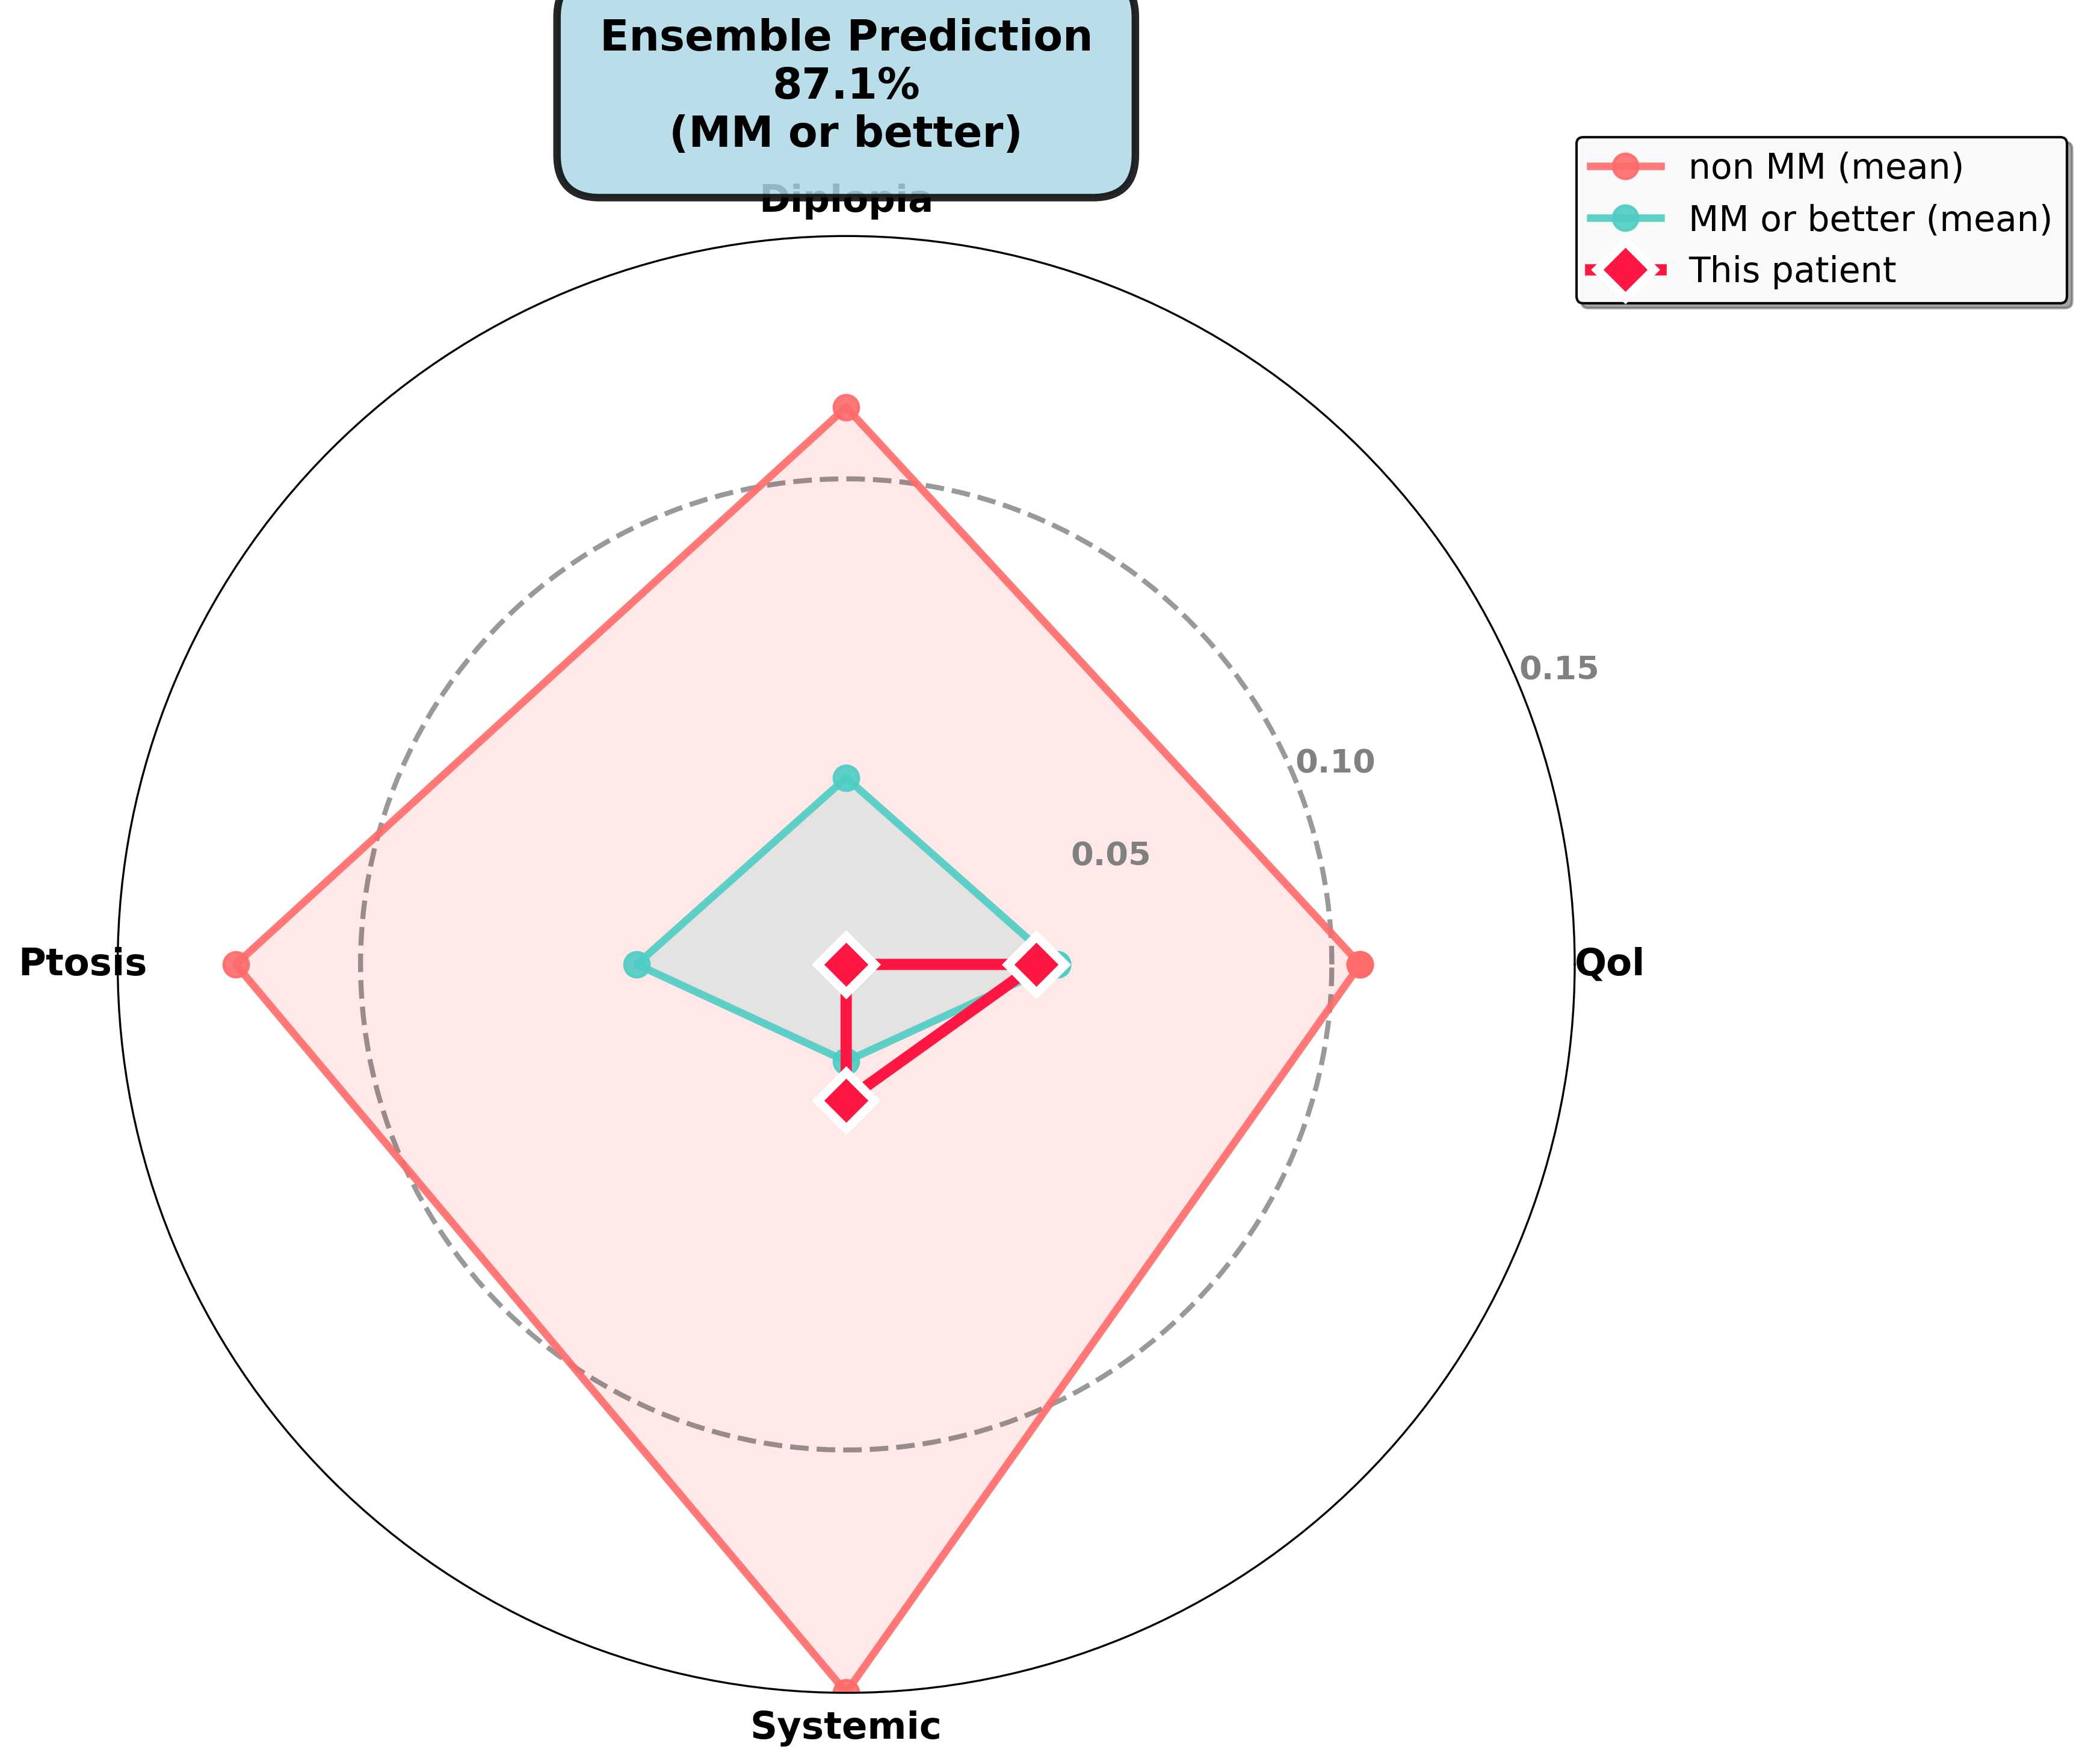


【Module Scores Comparison】
  Module  non MM (mean)  MM or better (mean)  This patient  Diff vs MM
     Qol         0.1058               0.0434        0.0391     -0.0043
Diplopia         0.1147               0.0384        0.0000     -0.0384
  Ptosis         0.1257               0.0431        0.0000     -0.0431
Systemic         0.1499               0.0200        0.0280      0.0081

【Module-wise Assessment】
✓ Qol         : 0.0391  [✓ Better than non-MM]
✓ Diplopia    : 0.0000  [✓ Better than non-MM]
✓ Ptosis      : 0.0000  [✓ Better than non-MM]
✓ Systemic    : 0.0280  [✓ Better than non-MM]

Ensemble Prediction:      0.871 (87.1%)
Classification:           MM or better


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

# --------------------
# 1) 既存ファイルから順序を復元
# --------------------
with open('./out/W_MM.pkl', 'rb') as f:
    W_MM = pickle.load(f)

module_names_ordered = [col for col in W_MM.columns if col not in ['ID', 'MMorbetter']]

print("復元されたモジュール順序:")
print(module_names_ordered)

# 保存
with open('./out/module_names_reordered.pkl', 'wb') as f:
    pickle.dump(module_names_ordered, f)

# --------------------
# 2) MM群/non MM群の平均値
# --------------------
MM_group = W_MM[W_MM["MMorbetter"] == 1][module_names_ordered].mean()
non_MM_group = W_MM[W_MM["MMorbetter"] == 0][module_names_ordered].mean()

# --------------------
# 3) 患者データ
# --------------------
patient_scores_original = X_validation.iloc[0].values.copy()

# --------------------
# 4) レーダーチャート（max 0.15）
# --------------------
def create_diamond_chart_015(patient_scores, MM_avg, non_MM_avg, 
                             module_names, ensemble_prob, 
                             save_path='./fig/prediction_radar.pdf'):
    """グリッドなし、0～0.15、はみ出し表示OK"""
    
    # データ保護
    patient_scores = patient_scores.copy()
    MM_avg = MM_avg.copy()
    non_MM_avg = non_MM_avg.copy()
    
    N = len(module_names)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    
    # 閉じた形にする
    patient_closed = np.concatenate([patient_scores, [patient_scores[0]]])
    MM_closed = np.concatenate([MM_avg, [MM_avg[0]]])
    non_MM_closed = np.concatenate([non_MM_avg, [non_MM_avg[0]]])
    angles_closed = angles + angles[:1]
    
    # 図作成
    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'), dpi=300)
    
    # max 0.15固定
    ax.set_ylim(0, 0.15)
    
    # 目盛り（0.05, 0.10, 0.15のみ）
    ax.set_yticks([0.05, 0.10, 0.15])
    ax.set_yticklabels(['0.05', '0.10', '0.15'], size=13, color='gray', weight='bold')
    
    # グリッドなし
    ax.grid(False)
    
    # 0.10の参照円のみ
    theta_full = np.linspace(0, 2*np.pi, 200)
    ax.plot(theta_full, np.ones_like(theta_full) * 0.10, 
            'k--', linewidth=2, alpha=0.4)
    
    # データプロット
    ax.fill(angles_closed, non_MM_closed, color='#FF6B6B', alpha=0.15)
    ax.plot(angles_closed, non_MM_closed, 'o-', linewidth=3, color='#FF6B6B', 
            label='non MM (mean)', alpha=0.9, markersize=10)
    
    ax.fill(angles_closed, MM_closed, color='#4ECDC4', alpha=0.15)
    ax.plot(angles_closed, MM_closed, 'o-', linewidth=3, color='#4ECDC4', 
            label='MM or better (mean)', alpha=0.9, markersize=10)
    
    # 患者データ（はみ出しても表示）
    ax.plot(angles_closed, patient_closed, 'D-', linewidth=4.5, color='#FF1744', 
            label='This patient', markersize=16, markeredgewidth=3.5, 
            markeredgecolor='white', zorder=10)
    
    # 軸ラベル
    ax.set_xticks(angles)
    labels = [name.replace('module ', '').title() for name in module_names]
    ax.set_xticklabels(labels, size=15, weight='bold')
    
    # 予測結果
    status = 'MM or better' if ensemble_prob > 0.5 else 'non MM'
    prediction_text = f"Ensemble Prediction\n{ensemble_prob:.1%}\n({status})"
    
    ax.text(0.5, 1.15, prediction_text, 
            transform=ax.transAxes, 
            ha='center', va='top',
            fontsize=17, weight='bold',
            bbox=dict(boxstyle='round,pad=1', 
                     facecolor='lightblue' if ensemble_prob > 0.5 else 'lightcoral', 
                     alpha=0.85, edgecolor='black', linewidth=3))
    
    # 凡例
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.08), 
              fontsize=14, framealpha=0.95, edgecolor='black', shadow=True)
    
    plt.tight_layout()
    
    import os
    os.makedirs('./fig', exist_ok=True)
    plt.savefig(save_path, format='pdf', dpi=600, bbox_inches='tight', transparent=True)
    plt.savefig(save_path.replace('.pdf', '.png'), format='png', dpi=300, bbox_inches='tight')
    
    print(f"\n✓ 図を保存: {save_path}")
    
    plt.show()
    return fig, ax

# --------------------
# 5) 実行
# --------------------
fig, ax = create_diamond_chart_015(
    patient_scores=patient_scores_original,
    MM_avg=MM_group.values,
    non_MM_avg=non_MM_group.values,
    module_names=module_names_ordered,
    ensemble_prob=ensemble_prob,
    save_path='./fig/prediction_radar.pdf'
)

# --------------------
# 6) 数値データ表示
# --------------------
print("\n" + "="*80)
print("【Module Scores Comparison】")
print("="*80)

comparison_df = pd.DataFrame({
    'Module': [name.replace('module ', '').title() for name in module_names_ordered],
    'non MM (mean)': non_MM_group.values.round(4),
    'MM or better (mean)': MM_group.values.round(4),
    'This patient': patient_scores_original.round(4),
    'Diff vs MM': (patient_scores_original - MM_group.values).round(4)
})

print(comparison_df.to_string(index=False))
print("="*80)

# モジュール別評価
print("\n【Module-wise Assessment】")
for i, module in enumerate(module_names_ordered):
    module_short = module.replace('module ', '').title()
    patient_val = patient_scores_original[i]
    mm_val = MM_group.values[i]
    non_mm_val = non_MM_group.values[i]
    
    if patient_val < non_mm_val:
        status = "✓ Better than non-MM"
        icon = "✓"
    elif patient_val > mm_val:
        status = "⚠ Worse than MM"
        icon = "⚠"
    else:
        status = "○ Between groups"
        icon = "○"
    
    print(f"{icon} {module_short:12s}: {patient_val:.4f}  [{status}]")

print("="*80)
print(f"\n{'Ensemble Prediction:':<25} {ensemble_prob:.3f} ({ensemble_prob:.1%})")
print(f"{'Classification:':<25} {'MM or better' if ensemble_prob > 0.5 else 'non MM'}")
print("="*80)